# 问卷数据分析

本分析笔记已整理为**可从上至下一次性运行**的流程，包含以下模块：

1. 环境与参数设置
2. 数据读取、清洗、编码与变量重命名
3. 描述性统计
4. 信度与效度分析
5. 潜在剖面分析
6. 人口统计学交叉分析、CBC分析与卡方检验
7. fsQCA 主模型、三解报告与稳健性分析

运行建议：
- 直接按顺序执行全部单元；
- 原始数据文件默认为同目录下的 `question.xlsx`；
- 图表与结果文件将保存到 `outputs/` 目录；

In [ ]:
import importlib
import subprocess
import sys
import warnings
from pathlib import Path

REQUIRED_PACKAGES = {
    'factor_analyzer': 'factor_analyzer',
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from cycler import cycler
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from scipy.stats import chi2_contingency
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import textwrap
from textwrap import fill
from itertools import product

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# 全局风格
# ---------------------------------------------------------------------------
青橙灰配色 = [
    '#2A9D8F', '#F4A261', '#7A7A7A', '#5E8B7E', '#E76F51',
    '#A6A6A6', '#4F6D7A', '#C9ADA7', '#84A59D', '#B0B7C3',
]
NATURE_COLORS = 青橙灰配色

标题字体 = fm.FontProperties(family=['Times New Roman', 'SimHei', 'Microsoft YaHei'], weight='bold')
正文字体 = fm.FontProperties(family=['Times New Roman', 'SimSun', 'STSong', 'Microsoft YaHei'])
数字英文字体 = fm.FontProperties(family=['Times New Roman', 'DejaVu Serif'])

matplotlib.rcParams['font.family'] = ['Times New Roman', 'SimSun', 'STSong', 'Microsoft YaHei', 'DejaVu Serif']
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

NATURE_RC = {
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'legend.frameon': False,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
    'grid.color': '#D9D9D9',
    'grid.linewidth': 0.5,
    'grid.linestyle': '--',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.prop_cycle': cycler(color=青橙灰配色),
    'mathtext.fontset': 'stix',
}
plt.rcParams.update(NATURE_RC)


def 设置图例字体(legend):
    if legend is None:
        return
    if legend.get_title() is not None:
        legend.get_title().set_fontproperties(标题字体)
    for text in legend.get_texts():
        text.set_fontproperties(正文字体)


def 设置色条字体(cbar, label: str | None = None):
    if label is not None:
        cbar.set_label(label)
    cbar.ax.yaxis.label.set_fontproperties(正文字体)
    for tick in cbar.ax.get_yticklabels():
        tick.set_fontproperties(数字英文字体)


def 应用整图字体(fig):
    for text in fig.findobj(match=lambda obj: isinstance(obj, matplotlib.text.Text)):
        raw_text = text.get_text().strip()
        weight = text.get_fontweight()
        is_title_like = (
            weight in ('bold', 'heavy', 'semibold')
            or text.get_fontsize() >= NATURE_RC['axes.titlesize']
            or raw_text.startswith('（')
            or raw_text.startswith('(')
        )
        if is_title_like:
            text.set_fontproperties(标题字体)
            text.set_fontweight('bold')
        else:
            text.set_fontproperties(正文字体)
            text.set_fontweight(weight)



def 设置中文论文图表(ax, title: str | None = None, xlabel: str | None = None, ylabel: str | None = None):
    """统一设置图表字体风格：标题黑体加粗，正文宋体，英文与数字优先 Times New Roman。"""
    if title is not None:
        title_obj = ax.set_title(title)
        title_obj.set_fontproperties(标题字体)
        title_obj.set_fontweight('bold')
    if xlabel is not None:
        ax.set_xlabel(xlabel)
        ax.xaxis.label.set_fontproperties(正文字体)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
        ax.yaxis.label.set_fontproperties(正文字体)

    for label in ax.get_xticklabels():
        label.set_fontproperties(正文字体)
    for label in ax.get_yticklabels():
        label.set_fontproperties(正文字体)

    设置图例字体(ax.get_legend())


PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'code',
    Path(r'c:\Users\Administrator\Desktop\正大杯\code'),
]
PROJECT_DIR = next((path for path in PROJECT_CANDIDATES if (path / 'question.xlsx').exists()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError('未找到 question.xlsx，请确认数据文件位于 notebook 同目录或 code/ 目录中。')

FILE_PATH = PROJECT_DIR / 'question.xlsx'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

ANALYSIS_CONFIG = {
    'min_completion_seconds': 60,
    'lpa_k_range': range(1, 7),
    'lpa_selected_k': 4,
    'gmm_n_init': 20,
    'gmm_max_iter': 500,
    'random_state': 42,
    'fsqca_consistency_threshold': 0.80,
    'fsqca_pri_threshold': 0.70,
    'fsqca_frequency_threshold': 1,
}

print('项目目录:', PROJECT_DIR.resolve())
print('数据文件:', FILE_PATH.resolve())
print('输出目录:', OUTPUT_DIR.resolve())
print('分析参数：')
display(pd.Series(ANALYSIS_CONFIG, name='取值').to_frame())

项目目录: C:\Users\Administrator\Desktop\正大杯\code
数据文件: C:\Users\Administrator\Desktop\正大杯\code\question.xlsx
输出目录: C:\Users\Administrator\Desktop\正大杯\code\outputs
分析参数：


,取值
min_completion_seconds,60
lpa_k_range,"(1, 2, 3, 4, 5, 6)"
lpa_selected_k,4
gmm_n_init,20
gmm_max_iter,500
random_state,42
fsqca_consistency_threshold,0.8
fsqca_pri_threshold,0.7
fsqca_frequency_threshold,1


In [81]:
# 数据读取与清洗
DROP_COLS = ['总分', '来自IP', '来源', '提交答卷时间', '序号', '来源详情']
TIME_COL = '所用时间'
ATTENTION_KEY = '请根据指令'
NEVER_USED_KEY = '从来没使用过AIGC产品'


def find_column(columns: list[str], keyword: str) -> str:
    matches = [col for col in columns if keyword in col]
    if not matches:
        raise KeyError(f'未找到包含“{keyword}”的列。')
    return matches[0]


def parse_seconds(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.extract(r'(\d+)', expand=False)
        .pipe(pd.to_numeric, errors='coerce')
        .astype('Int64')
    )


def clean_sheet(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    df = df.copy()
    attention_col = find_column(df.columns.tolist(), ATTENTION_KEY)
    never_used_col = find_column(df.columns.tolist(), NEVER_USED_KEY)

    df[TIME_COL] = parse_seconds(df[TIME_COL])

    masks = {
        'speeders': df[TIME_COL].fillna(0) < ANALYSIS_CONFIG['min_completion_seconds'],
        'attention_fail': pd.to_numeric(df[attention_col], errors='coerce').fillna(0) > 1,
        'never_used': pd.to_numeric(df[never_used_col], errors='coerce').fillna(0) >= 4,
    }
    invalid_mask = masks['speeders'] | masks['attention_fail'] | masks['never_used']

    cleaned = df.loc[~invalid_mask].copy()
    cleaned = cleaned.drop(columns=[col for col in DROP_COLS if col in cleaned.columns])
    cleaned[TIME_COL] = cleaned[TIME_COL].fillna(0).astype(int)

    summary = {
        'raw_n': len(df),
        'valid_n': len(cleaned),
        'removed_n': int(invalid_mask.sum()),
        'speeders_n': int(masks['speeders'].sum()),
        'attention_fail_n': int(masks['attention_fail'].sum()),
        'never_used_n': int(masks['never_used'].sum()),
    }
    return cleaned, summary

xls = pd.ExcelFile(FILE_PATH)
raw_data = {sheet: pd.read_excel(FILE_PATH, sheet_name=sheet) for sheet in xls.sheet_names}
sheet_text_data = {}
cleaning_summary = []

for sheet_name, df in raw_data.items():
    cleaned_df, summary = clean_sheet(df)
    sheet_text_data[sheet_name] = cleaned_df
    cleaning_summary.append({'sheet': sheet_name, **summary})

cleaning_summary_df = pd.DataFrame(cleaning_summary)
print('数据清洗完成。')
display(cleaning_summary_df)

数据清洗完成。


,sheet,raw_n,valid_n,removed_n,speeders_n,attention_fail_n,never_used_n
0,Sheet1,801,416,385,0,350,150


In [82]:
# 类别变量编码

ENCODING_MAPS = {
    '1、请问您是否使用过生成式AI工具，如豆包、Kimi、文心一言、智谱清言等': {
        '偶尔使用，每月几次或仅体验过': 1,
        '经常使用，每天或每周多次': 2,
    },
    '18、如果您必须在以下两款软件中选择一款，您倾向于：': {
        '都不选，我选择维持现状，不用AI或用现有的其他免费工具': 0,
        '产品A：不保留您的历史记忆，仅做单次任务；直接给结果；完全免费': 1,
        '产品B：深度学习您的偏好，主动提供建议；提供完整的推理步骤与信源；150元/月': 2,
    },
    '19、如果您必须在以下两款软件中选择一款，您倾向于：': {
        '都不选，我选择维持现状': 0,
        '产品A：深度学习您的偏好；直接给结果；150元/月': 1,
        '产品B：仅做单次任务不留记忆；提供完整的推理步骤与信源；完全免费': 2,
    },
    '20、如果在上述功能基础上加入"控制权"选项，您更偏好：': {
        '自动帮您完成排版、修改并直接发送或提交': 0,
        '仅提供草稿，每个关键步骤强制要求您手动点击确认': 1,
    },
    '21、您的性别：': {'女': 0, '男': 1},
    '22、您的年龄段：': {
        '18岁以下': 1, '18~25': 2, '26~30': 3,
        '31~40': 4, '41~50': 5, '51~60': 6,
    },
    '23、您目前的职业：': {
        '在读学生': 1, '企业职员': 2, '政府或事业单位工作人员': 3,
        '高校、科研机构': 4, '文化、传媒、设计或创意从业者': 5, '自由职业者': 6,
    },
    '24、您的学历：': {
        '小学': 1, '初中': 2,
        '高中（含普通高中、职业高中、中专、技校等）': 3,
        '专科': 4, '本科': 5, '硕士研究生': 6, '博士研究生': 7,
    },
    '25、您平均每天使用AIGC工具的时间大约是：': {
        '不到半小时': 1, '半小时 - 1小时': 2,
        '1小时 - 3小时': 3, '3小时以上': 4,
    },
    '26、您目前是否有为任何一款AIGC工具付费：': {
        '否，一直只使用免费版': 0,
        '曾经付费过，但目前已停用或退订': 1,
        '是，一直在持续付费': 2,
    },
}

codebook_df = pd.DataFrame(
    [
        {'变量': column, '原始文本': text, '赋值': code}
        for column, mapping in ENCODING_MAPS.items()
        for text, code in mapping.items()
    ]
)

sheet_data = {}
encoding_issue_rows = []

for sheet_name, df in sheet_text_data.items():
    encoded = df.copy()
    for column, mapping in ENCODING_MAPS.items():
        if column not in encoded.columns:
            continue
        observed = set(encoded[column].dropna().astype(str))
        expected = set(mapping.keys())
        unmapped = sorted(observed - expected)
        if unmapped:
            encoding_issue_rows.append({
                'sheet': sheet_name,
                'column': column,
                'unmapped_values': ' | '.join(map(str, unmapped)),
            })
        encoded[column] = encoded[column].map(mapping)
    sheet_data[sheet_name] = encoded

encoding_issues_df = pd.DataFrame(encoding_issue_rows)
print('编码字典：')
display(codebook_df)
print('未编码值检查：')
display(encoding_issues_df if not encoding_issues_df.empty else pd.DataFrame({'状态': ['无未映射取值']}))

编码字典：


,变量,原始文本,赋值
0,1、请问您是否使用过生成式AI工具，如豆包、Kimi、文心一言、智谱清言等,偶尔使用，每月几次或仅体验过,1
1,1、请问您是否使用过生成式AI工具，如豆包、Kimi、文心一言、智谱清言等,经常使用，每天或每周多次,2
2,18、如果您必须在以下两款软件中选择一款，您倾向于：,都不选，我选择维持现状，不用AI或用现有的其他免费工具,0
3,18、如果您必须在以下两款软件中选择一款，您倾向于：,产品A：不保留您的历史记忆，仅做单次任务；直接给结果；完全免费,1
4,18、如果您必须在以下两款软件中选择一款，您倾向于：,产品B：深度学习您的偏好，主动提供建议；提供完整的推理步骤与信源；150元/月,2
5,19、如果您必须在以下两款软件中选择一款，您倾向于：,都不选，我选择维持现状,0
6,19、如果您必须在以下两款软件中选择一款，您倾向于：,产品A：深度学习您的偏好；直接给结果；150元/月,1
7,19、如果您必须在以下两款软件中选择一款，您倾向于：,产品B：仅做单次任务不留记忆；提供完整的推理步骤与信源；完全免费,2
8,"20、如果在上述功能基础上加入""控制权""选项，您更偏好：",自动帮您完成排版、修改并直接发送或提交,0
9,"20、如果在上述功能基础上加入""控制权""选项，您更偏好：",仅提供草稿，每个关键步骤强制要求您手动点击确认,1


未编码值检查：


,状态
0,无未映射取值


In [83]:
# 变量重命名与分析数据集构建
PREFIX_TO_NAME = {
    '所用时间': '答题时长秒',
    '1、': 'AI使用频率',
    '2、': '任务依赖度',
    '3、': '效率焦虑',
    '4、': '任务外包倾向',
    '5、': '竞争担忧',
    '6、': '岗位替代恐惧',
    '7、': '学习压力',
    '8、': '错失焦虑',
    '9、': '注意力检验',
    '10、': '工作量增加感',
    '11、': '黑箱谨慎',
    '12、': '解释需求',
    '13、': '控制需求',
    '14、': '助手偏好',
    '15、': '黑箱拒绝',
    '16、': '依赖降低意愿',
    '17、': '从未使用AI',
    '18、': '选择偏好1',
    '19、': '选择偏好2',
    '20、': '控制权偏好',
    '21、': '性别',
    '22、': '年龄',
    '23、': '职业',
    '24、': '学历',
    '25、': '日均AI使用时长',
    '26、': 'AI付费状态',
}

AUXILIARY_COLS = ['注意力检验', '从未使用AI', '答题时长秒']
RESISTANCE_ITEMS = ['黑箱拒绝', '依赖降低意愿']
RELIABILITY_DIMENSIONS = {
    '依赖度与替代焦虑': [
        '任务依赖度',
        '效率焦虑',
        '任务外包倾向',
        '竞争担忧',
        '岗位替代恐惧',
        '学习压力',
        '错失焦虑',
        '工作量增加感',
    ],
    '透明度与控制感': [
        '黑箱谨慎',
        '解释需求',
        '控制需求',
        '助手偏好',
    ],
}

ITEM_SHORT_LABELS = {
    '任务依赖度': '任务\n依赖度',
    '效率焦虑': '效率\n焦虑',
    '任务外包倾向': '任务\n外包',
    '竞争担忧': '竞争\n担忧',
    '岗位替代恐惧': '岗位替代\n恐惧',
    '学习压力': '学习\n压力',
    '错失焦虑': '错失\n焦虑',
    '工作量增加感': '工作量\n增加感',
    '黑箱谨慎': '黑箱\n谨慎',
    '解释需求': '解释\n需求',
    '控制需求': '控制\n需求',
    '助手偏好': '助手\n偏好',
}

VAR_META = {
    '性别': {
        'label': '性别',
        'cats': {0: '女', 1: '男'},
    },
    '年龄段': {
        'label': '年龄段',
        'cats': {1: '18岁以下', 2: '18~25岁', 3: '26~30岁', 4: '31~40岁', 5: '41~50岁', 6: '51~60岁'},
    },
    '学历': {
        'label': '学历',
        'cats': {1: '小学', 2: '初中', 3: '高中/中专/技校', 4: '专科', 5: '本科', 6: '硕士', 7: '博士'},
    },
    '职业': {
        'label': '职业',
        'cats': {1: '在读学生', 2: '企业职员', 3: '政府/事业单位', 4: '高校/科研机构', 5: '文化传媒/设计创意', 6: '自由职业者'},
    },
    '日均AI使用时长': {
        'label': '日均AI使用时长',
        'cats': {1: '不到半小时', 2: '半小时~1小时', 3: '1~3小时', 4: '3小时以上'},
    },
    'AI付费状态': {
        'label': 'AI付费状态',
        'cats': {0: '仅使用免费版', 1: '曾付费现已停用', 2: '持续付费中'},
    },
    'AI使用频率': {
        'label': 'AI使用频率',
        'cats': {1: '偶尔使用', 2: '经常使用'},
    },
}


def build_rename_map(columns: list[str], prefix_map: dict[str, str]) -> dict[str, str]:
    rename_map = {}
    for column in columns:
        for prefix, new_name in prefix_map.items():
            if column == prefix or column.startswith(prefix):
                rename_map[column] = new_name
                break
    return rename_map


sample_columns = list(next(iter(sheet_text_data.values())).columns)
RENAME_MAP = build_rename_map(sample_columns, PREFIX_TO_NAME)

sheet_text_data = {sheet: df.rename(columns=RENAME_MAP).copy() for sheet, df in sheet_text_data.items()}
sheet_data = {sheet: df.rename(columns=RENAME_MAP).copy() for sheet, df in sheet_data.items()}

for sheet_name in sheet_data:
    sheet_data[sheet_name] = sheet_data[sheet_name].drop(
        columns=[col for col in AUXILIARY_COLS if col in sheet_data[sheet_name].columns]
    )
    sheet_text_data[sheet_name] = sheet_text_data[sheet_name].drop(
        columns=[col for col in AUXILIARY_COLS if col in sheet_text_data[sheet_name].columns]
    )

all_scale_items = [item for items in RELIABILITY_DIMENSIONS.values() for item in items]
analysis_sheet_data = {
    sheet: df[all_scale_items].dropna().copy()
    for sheet, df in sheet_data.items()
}

sheet1_numeric = sheet_data['Sheet1'].copy()
sheet1_text = sheet_text_data['Sheet1'].copy()
antecedent_df = analysis_sheet_data['Sheet1'].copy()
resistance_df = sheet1_numeric[RESISTANCE_ITEMS].dropna().copy()

DIM1_ITEMS = RELIABILITY_DIMENSIONS['依赖度与替代焦虑']
DIM2_ITEMS = RELIABILITY_DIMENSIONS['透明度与控制感']
DIMENSION_VAR_NAMES = {
    '依赖度与替代焦虑': '依赖度与替代焦虑均值',
    '透明度与控制感': '透明度与控制感均值',
}
OUTCOME_VAR = '抵抗意愿'

rename_table = pd.DataFrame([{'原列名': old, '新变量名': new} for old, new in RENAME_MAP.items()])
print('变量重命名表：')
display(rename_table)
print('可分析变量：')
display(pd.DataFrame({'变量名': sheet1_numeric.columns.tolist()}))

变量重命名表：


,原列名,新变量名
0,所用时间,答题时长秒
1,1、请问您是否使用过生成式AI工具，如豆包、Kimi、文心一言、智谱清言等,AI使用频率
2,2、我发现自己越来越难以在不借助AIGC工具的情况下完成复杂的文案或代码工作,任务依赖度
3,3、如果某天无法访问AIGC工具，我会感到明显的效率焦虑和无所适从,效率焦虑
4,4、我现在倾向于把哪怕是很基础的思考任务，也优先交给AIGC来打底,任务外包倾向
5,5、看到AIGC生成的高质量内容，我经常担心自己未来的核心竞争力会被削弱,竞争担忧
6,6、我害怕在不久的将来，我所在的岗位或专业会被AIGC大规模替代,岗位替代恐惧
7,7、AIGC工具的快速迭代让我感到一种“如果不拼命学就会被淘汰”的巨大压力,学习压力
8,8、看到身边的同学或同事都在熟练使用AIGC，我会产生强烈的错失恐惧,错失焦虑
9,9、请根据指令，在此题选择“很不同意”,注意力检验


可分析变量：


,变量名
0,AI使用频率
1,任务依赖度
2,效率焦虑
3,任务外包倾向
4,竞争担忧
5,岗位替代恐惧
6,学习压力
7,错失焦虑
8,工作量增加感
9,黑箱谨慎


In [53]:
# 描述性统计
def descriptive_stats(df: pd.DataFrame) -> pd.DataFrame:
    numeric_df = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    if numeric_df.empty:
        return pd.DataFrame()

    stats = numeric_df.describe().T
    stats['偏度'] = numeric_df.skew(numeric_only=True)
    stats['峰度'] = numeric_df.kurt(numeric_only=True)
    return stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', '偏度', '峰度']]


descriptive_tables = {}
for sheet_name, df in sheet_data.items():
    descriptive_tables[sheet_name] = descriptive_stats(df).round(4)

for sheet_name, table in descriptive_tables.items():
    print(f'描述性统计：{sheet_name}')
    display(table)

描述性统计：Sheet1


,count,mean,std,min,25%,50%,75%,max,偏度,峰度
AI使用频率,416.0,1.6514,0.4771,1.0,1.0,2.0,2.0,2.0,-0.6379,-1.6008
任务依赖度,416.0,4.2212,2.1619,1.0,2.0,5.0,6.0,7.0,-0.2385,-1.3925
效率焦虑,416.0,4.3678,2.0598,1.0,3.0,5.0,6.0,7.0,-0.2456,-1.2643
任务外包倾向,416.0,4.4399,2.1071,1.0,3.0,5.0,6.0,7.0,-0.3737,-1.2382
竞争担忧,416.0,4.2476,2.0996,1.0,2.0,5.0,6.0,7.0,-0.1560,-1.3665
岗位替代恐惧,416.0,4.1562,2.0981,1.0,2.0,4.0,6.0,7.0,-0.1371,-1.4004
学习压力,416.0,4.3678,2.0563,1.0,3.0,5.0,6.0,7.0,-0.2266,-1.2720
错失焦虑,416.0,4.3245,2.0007,1.0,2.0,5.0,6.0,7.0,-0.2075,-1.2687
工作量增加感,416.0,4.3221,2.0469,1.0,2.0,5.0,6.0,7.0,-0.1542,-1.3281
黑箱谨慎,416.0,4.3029,1.9987,1.0,3.0,5.0,6.0,7.0,-0.2493,-1.1927


In [55]:
# 信度分析
def cronbach_alpha(df_sub: pd.DataFrame) -> float:
    df_sub = df_sub.dropna()
    n_items = df_sub.shape[1]
    if n_items < 2:
        return np.nan
    total_score = df_sub.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    if total_variance == 0:
        return np.nan
    item_variances = df_sub.var(axis=0, ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)


def item_total_analysis(df_sub: pd.DataFrame) -> tuple[float, pd.DataFrame]:
    df_sub = df_sub.dropna()
    alpha_value = cronbach_alpha(df_sub)
    rows = []
    for column in df_sub.columns:
        rest_score = df_sub.drop(columns=column).sum(axis=1)
        citc = df_sub[column].corr(rest_score)
        alpha_if_deleted = cronbach_alpha(df_sub.drop(columns=column))
        rows.append({
            '题项': column,
            'CITC': citc,
            '删除该题项后的α': alpha_if_deleted,
        })
    return alpha_value, pd.DataFrame(rows)

reliability_summary_rows = []
reliability_detail_tables = {}

for dim_name, dim_items in RELIABILITY_DIMENSIONS.items():
    alpha_value, detail_df = item_total_analysis(antecedent_df[dim_items])
    reliability_detail_tables[dim_name] = detail_df.round(4)
    reliability_summary_rows.append({
        '维度': dim_name,
        '题项数': len(dim_items),
        'Cronbach α': round(alpha_value, 4),
        'CITC最小值': round(detail_df['CITC'].min(), 4),
        'CITC最大值': round(detail_df['CITC'].max(), 4),
        '删除题项后α最大值': round(detail_df['删除该题项后的α'].max(), 4),
    })

overall_alpha, overall_detail = item_total_analysis(antecedent_df[all_scale_items])
reliability_summary_rows.append({
    '维度': '整体量表',
    '题项数': len(all_scale_items),
    'Cronbach α': round(overall_alpha, 4),
    'CITC最小值': round(overall_detail['CITC'].min(), 4),
    'CITC最大值': round(overall_detail['CITC'].max(), 4),
    '删除题项后α最大值': round(overall_detail['删除该题项后的α'].max(), 4),
})

reliability_summary_table = pd.DataFrame(reliability_summary_rows)
print('信度汇总表：')
display(reliability_summary_table)

for dim_name, detail_df in reliability_detail_tables.items():
    print(f'题项分析：{dim_name}')
    display(detail_df)

print('题项分析：整体量表')
display(overall_detail.round(4))

信度汇总表：


,维度,题项数,Cronbach α,CITC最小值,CITC最大值,删除题项后α最大值
0,依赖度与替代焦虑,8,0.9022,0.6572,0.7234,0.8928
1,透明度与控制感,4,0.8293,0.6364,0.6704,0.7934
2,整体量表,12,0.9348,0.6748,0.7516,0.9307


题项分析：依赖度与替代焦虑


,题项,CITC,删除该题项后的α
0,任务依赖度,0.6954,0.8894
1,效率焦虑,0.6783,0.8909
2,任务外包倾向,0.6572,0.8928
3,竞争担忧,0.6987,0.8890
4,岗位替代恐惧,0.7211,0.8870
5,学习压力,0.6836,0.8904
6,错失焦虑,0.7234,0.8869
7,工作量增加感,0.6678,0.8918


题项分析：透明度与控制感


,题项,CITC,删除该题项后的α
0,黑箱谨慎,0.6364,0.7934
1,解释需求,0.6580,0.7838
2,控制需求,0.6704,0.7781
3,助手偏好,0.6595,0.7831


题项分析：整体量表


,题项,CITC,删除该题项后的α
0,任务依赖度,0.7118,0.9293
1,效率焦虑,0.6969,0.9298
2,任务外包倾向,0.6748,0.9307
3,竞争担忧,0.7150,0.9291
4,岗位替代恐惧,0.7349,0.9284
5,学习压力,0.6881,0.9301
6,错失焦虑,0.7516,0.9278
7,工作量增加感,0.6846,0.9302
8,黑箱谨慎,0.6908,0.9300
9,解释需求,0.7370,0.9283


In [56]:
# 效度分析
def varimax(loadings: np.ndarray, max_iter: int = 1000, tol: float = 1e-6) -> np.ndarray:
    n_rows, n_cols = loadings.shape
    rotation = np.eye(n_cols)
    criterion = 0.0

    for _ in range(max_iter):
        rotated = loadings @ rotation
        basis = loadings.T @ (
            rotated ** 3
            - (1.0 / n_rows) * rotated @ np.diag(np.einsum('ij,ij->j', rotated, rotated))
        )
        u, singular_values, vh = np.linalg.svd(basis)
        rotation = u @ vh
        new_criterion = singular_values.sum()
        if abs(new_criterion - criterion) < tol:
            break
        criterion = new_criterion

    return loadings @ rotation

kmo_per_item, kmo_overall = calculate_kmo(antecedent_df)
bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(antecedent_df)

kmo_bartlett_table = pd.DataFrame({
    '检验项目': ['KMO 测度值', 'Bartlett 球形检验 χ²', '显著性 p 值'],
    '统计量': [round(kmo_overall, 4), round(bartlett_chi2, 4), f'{bartlett_p:.2e}'],
    '判断标准': ['> 0.70', '越大越好', '< 0.05'],
})

X_std = StandardScaler().fit_transform(antecedent_df)
corr_matrix = np.corrcoef(X_std.T)
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

N_FACTORS = 2
initial_loadings = eigenvectors[:, :N_FACTORS] * np.sqrt(np.maximum(eigenvalues[:N_FACTORS], 0))
rotated_loadings = varimax(initial_loadings)

for factor_idx in range(N_FACTORS):
    if rotated_loadings[:, factor_idx].sum() < 0:
        rotated_loadings[:, factor_idx] *= -1

FACTOR_LABELS = ['因子1（依赖度与替代焦虑）', '因子2（透明度与控制感）']
item_dimension_map = {item: dim for dim, items in RELIABILITY_DIMENSIONS.items() for item in items}

loading_table = pd.DataFrame(rotated_loadings, index=all_scale_items, columns=FACTOR_LABELS)
loading_table.insert(0, '所属维度', [item_dimension_map[item] for item in loading_table.index])

ss_loadings = (rotated_loadings ** 2).sum(axis=0)
prop_variance = ss_loadings / len(all_scale_items)
cumul_variance = np.cumsum(prop_variance)
variance_table = pd.DataFrame({
    '因子': FACTOR_LABELS,
    'SS Loadings': np.round(ss_loadings, 4),
    '方差解释率（%）': np.round(prop_variance * 100, 2),
    '累积方差解释率（%）': np.round(cumul_variance * 100, 2),
})

pearson_r = resistance_df[RESISTANCE_ITEMS[0]].corr(resistance_df[RESISTANCE_ITEMS[1]])
X_res = StandardScaler().fit_transform(resistance_df)
evals_r, evecs_r = np.linalg.eigh(np.corrcoef(X_res.T))
lead_idx = np.argsort(evals_r)[::-1][0]
single_factor_loading = evecs_r[:, lead_idx] * np.sqrt(max(evals_r[lead_idx], 0))
if single_factor_loading.sum() < 0:
    single_factor_loading *= -1

resistance_validity_table = pd.DataFrame({
    '题项': RESISTANCE_ITEMS,
    '所属维度': ['抵抗意愿（结果变量）'] * len(RESISTANCE_ITEMS),
    '单因子载荷': np.round(single_factor_loading, 4),
    'Pearson r（题间）': [f'{pearson_r:.4f}', '—'],
})

print('KMO 与 Bartlett 检验：')
display(kmo_bartlett_table)
print('旋转载荷矩阵：')
display(loading_table.round(4))
print('方差解释表：')
display(variance_table)
print('结果变量聚合效度：')
display(resistance_validity_table)

KMO 与 Bartlett 检验：


,检验项目,统计量,判断标准
0,KMO 测度值,0.9699,> 0.70
1,Bartlett 球形检验 χ²,2817.1949,越大越好
2,显著性 p 值,0.00e+00,< 0.05


旋转载荷矩阵：


,所属维度,因子1（依赖度与替代焦虑）,因子2（透明度与控制感）
任务依赖度,依赖度与替代焦虑,0.5227,0.5578
效率焦虑,依赖度与替代焦虑,0.3632,0.7006
任务外包倾向,依赖度与替代焦虑,0.3950,0.6388
竞争担忧,依赖度与替代焦虑,0.5585,0.5256
岗位替代恐惧,依赖度与替代焦虑,0.5678,0.5410
学习压力,依赖度与替代焦虑,0.7573,0.2885
错失焦虑,依赖度与替代焦虑,0.5605,0.5705
工作量增加感,依赖度与替代焦虑,0.8066,0.2334
黑箱谨慎,透明度与控制感,0.2215,0.8362
解释需求,透明度与控制感,0.6331,0.4784


方差解释表：


,因子,SS Loadings,方差解释率（%）,累积方差解释率（%）
0,因子1（依赖度与替代焦虑）,3.8545,32.12,32.12
1,因子2（透明度与控制感）,3.7500,31.25,63.37


结果变量聚合效度：


,题项,所属维度,单因子载荷,Pearson r（题间）
0,黑箱拒绝,抵抗意愿（结果变量）,0.8766,0.5368
1,依赖降低意愿,抵抗意愿（结果变量）,0.8766,—


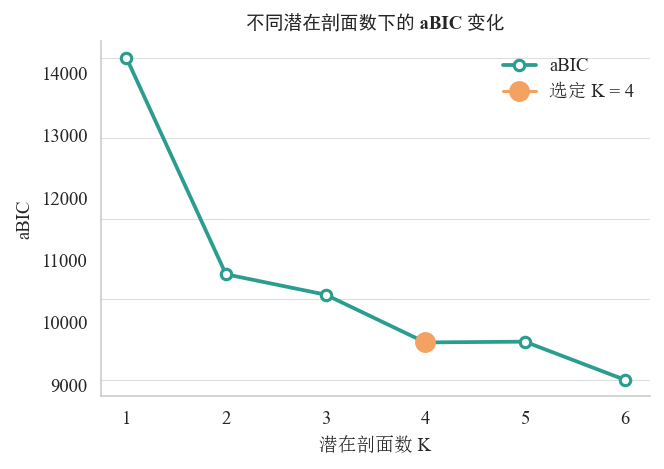

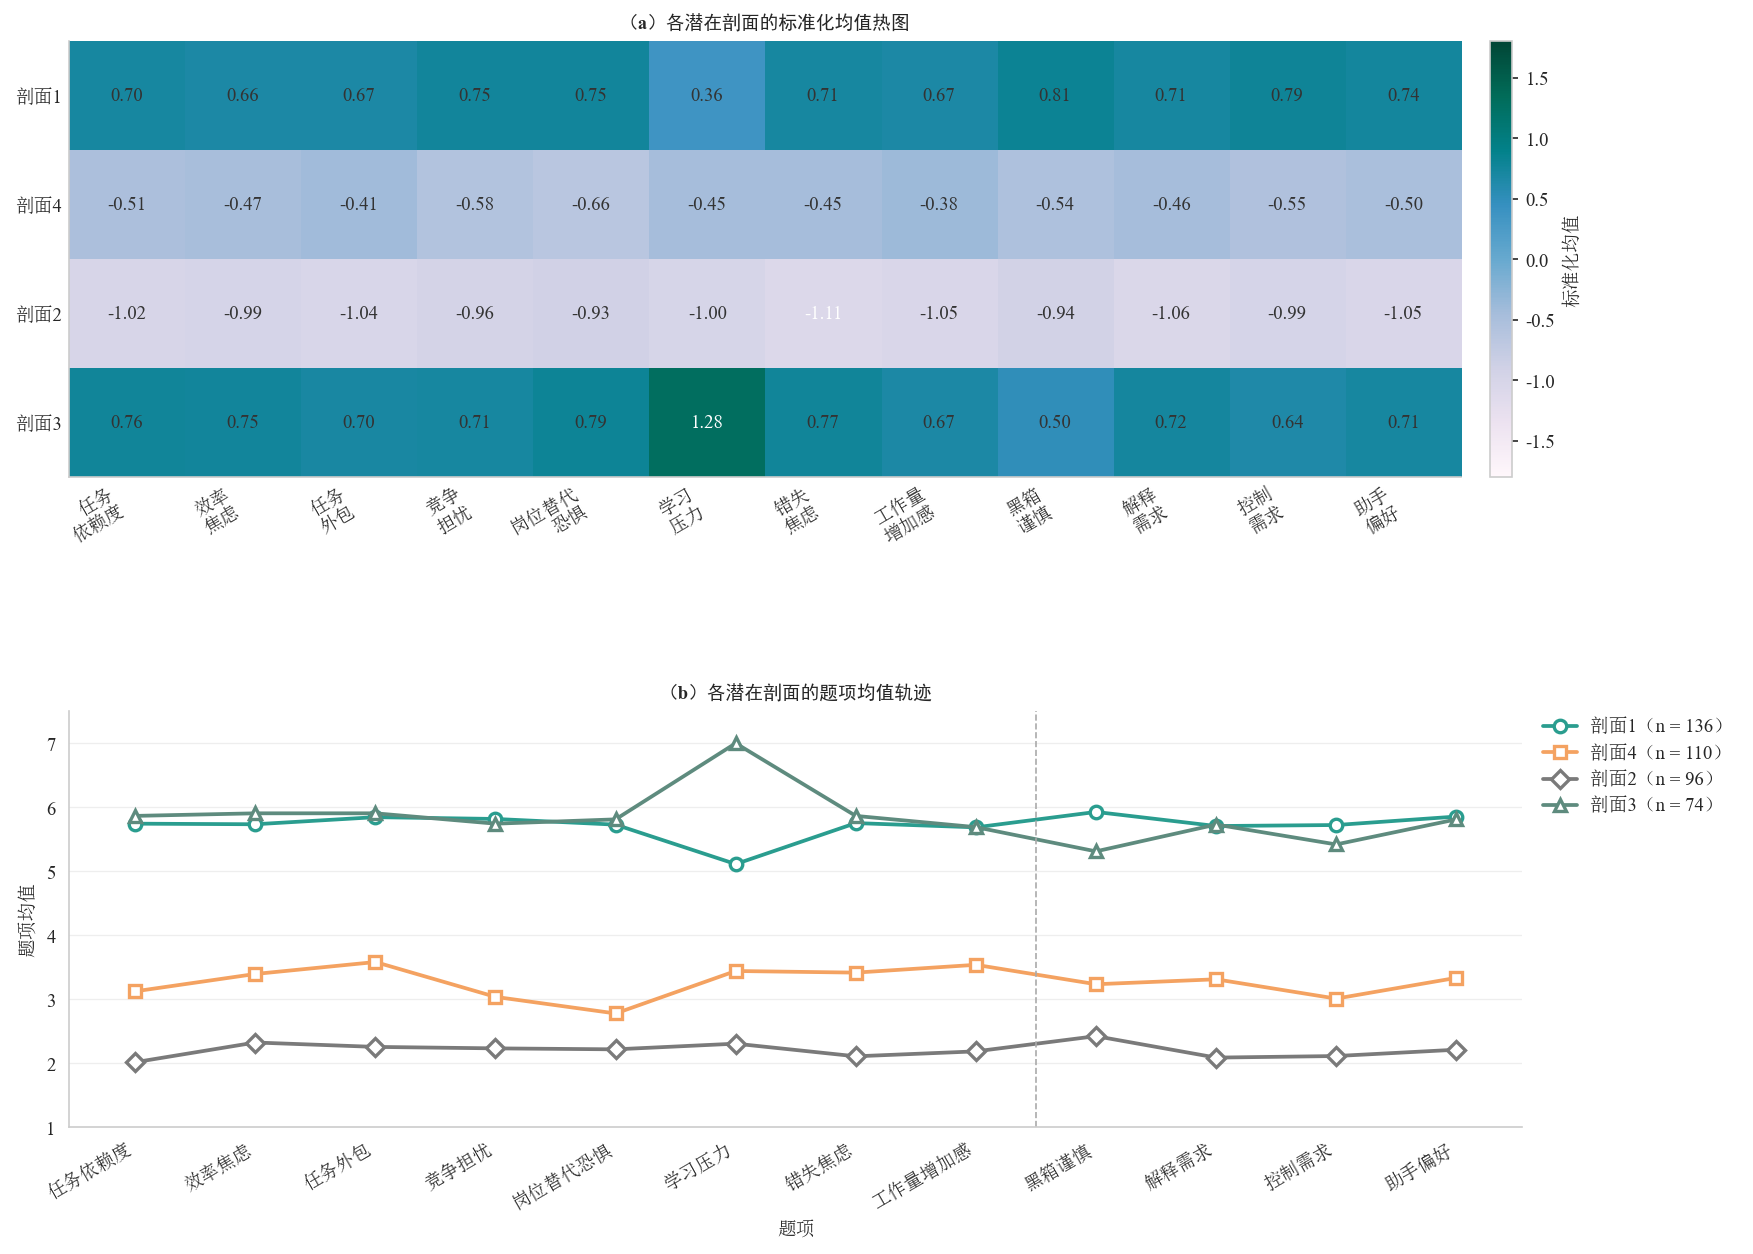

LPA 拟合指标：


,剖面数 K,对数似然,自由参数数,BIC,aBIC,Entropy
0,1,-7083.3412,24,14311.4188,14235.2606,—
1,2,-5310.5815,49,10916.6666,10761.1769,0.9998
2,3,-5111.4952,74,10669.2612,10434.4401,0.9582
3,4,-4693.0350,99,9983.1079,9668.9554,0.9666
4,5,-4663.3312,124,10074.4674,9680.9834,0.9131
5,6,-4322.7464,149,9544.0648,9071.2494,0.9728


自动肘部法建议 K = 2；当前采用 K = 4
LPA 剖面特征表：


,潜在剖面,样本量,占比（%）,任务依赖度,效率焦虑,任务外包倾向,竞争担忧,岗位替代恐惧,学习压力,错失焦虑,工作量增加感,黑箱谨慎,解释需求,控制需求,助手偏好
0,剖面1,136,32.69,5.7426,5.7353,5.8456,5.8162,5.7279,5.1103,5.7500,5.6838,5.9265,5.7059,5.7206,5.8529
1,剖面2,96,23.08,2.0208,2.3438,2.2708,2.2396,2.2188,2.3438,2.1146,2.1979,2.3854,2.1042,2.1042,2.2188
2,剖面3,74,17.79,5.8649,5.9054,5.9054,5.7432,5.8108,7.0000,5.8649,5.6892,5.3108,5.7297,5.4189,5.8108
3,剖面4,110,26.44,3.1545,3.4091,3.6091,3.0545,2.7909,3.4455,3.4545,3.5727,3.2909,3.3364,3.0455,3.3636


lpa_result shape: (416, 13)


In [84]:
# 潜在剖面分析
K_RANGE = ANALYSIS_CONFIG['lpa_k_range']
N_INIT = ANALYSIS_CONFIG['gmm_n_init']
MAX_ITER = ANALYSIS_CONFIG['gmm_max_iter']
SEED = ANALYSIS_CONFIG['random_state']
MANUAL_LPA_K = ANALYSIS_CONFIG['lpa_selected_k']


def free_params(k: int, p: int) -> int:
    return k * (2 * p + 1) - 1


def abic(log_likelihood: float, k: int, p: int, n: int) -> float:
    return -2.0 * log_likelihood + free_params(k, p) * np.log((n + 2.0) / 24.0)


def classification_entropy(posteriors: np.ndarray) -> float:
    n, k = posteriors.shape
    if k == 1:
        return np.nan
    clipped = np.clip(posteriors, 1e-300, 1.0)
    entropy_mass = -np.sum(clipped * np.log(clipped))
    return 1.0 - entropy_mass / (n * np.log(k))


def elbow_k(values: list[float]) -> int:
    xs = np.linspace(0.0, 1.0, len(values))
    ys = (np.array(values) - min(values)) / (max(values) - min(values) + 1e-12)
    dx, dy = xs[-1] - xs[0], ys[-1] - ys[0]
    norm = np.hypot(dx, dy)
    distances = np.abs(dy * xs - dx * ys + xs[-1] * ys[0] - ys[-1] * xs[0]) / norm
    return int(np.argmax(distances)) + 1


lpa_raw = antecedent_df.copy()
scaler_lpa = StandardScaler()
lpa_scaled = scaler_lpa.fit_transform(lpa_raw)
N_OBS, N_VARS = lpa_scaled.shape

fit_records = []
fitted_gmms = {}

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=SEED,
    )
    gmm.fit(lpa_scaled)

    log_lik = gmm.score(lpa_scaled) * N_OBS
    posteriors = gmm.predict_proba(lpa_scaled)
    fit_records.append({
        '剖面数 K': k,
        '对数似然': round(log_lik, 4),
        '自由参数数': free_params(k, N_VARS),
        'BIC': round(-2.0 * log_lik + free_params(k, N_VARS) * np.log(N_OBS), 4),
        'aBIC': round(abic(log_lik, k, N_VARS, N_OBS), 4),
        'Entropy': round(classification_entropy(posteriors), 4) if k > 1 else '—',
    })
    fitted_gmms[k] = gmm

fit_table = pd.DataFrame(fit_records)
abic_values = fit_table['aBIC'].astype(float).tolist()
auto_k = elbow_k(abic_values)
optimal_k = MANUAL_LPA_K if MANUAL_LPA_K is not None else auto_k

best_gmm = fitted_gmms[optimal_k]
assignments = best_gmm.predict(lpa_scaled)
posteriors_k = best_gmm.predict_proba(lpa_scaled)
gmm_means_raw = scaler_lpa.inverse_transform(best_gmm.means_)

profile_sizes = {k: int(np.sum(assignments == k)) for k in range(optimal_k)}
sorted_by_size = np.argsort(list(profile_sizes.values()))[::-1]
profile_labels = [f'剖面{i + 1}' for i in range(optimal_k)]

lpa_result = lpa_raw.copy()
lpa_result['潜在剖面'] = assignments

profile_rows = []
for k in range(optimal_k):
    subset = lpa_result[lpa_result['潜在剖面'] == k]
    row = {
        '潜在剖面': profile_labels[k],
        '样本量': len(subset),
        '占比（%）': round(len(subset) / N_OBS * 100, 2),
    }
    for item in all_scale_items:
        row[item] = round(subset[item].mean(), 4)
    profile_rows.append(row)

profile_table = pd.DataFrame(profile_rows)

fig1, ax1 = plt.subplots(figsize=(4.5, 3.2))
ks = list(K_RANGE)
ax1.plot(
    ks,
    abic_values,
    color=青橙灰配色[0],
    linewidth=1.8,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5,
    zorder=3,
    label='aBIC',
)
ax1.plot(
    optimal_k,
    abic_values[optimal_k - 1],
    marker='o',
    markersize=9,
    color=青橙灰配色[1],
    zorder=4,
    label=f'选定 K = {optimal_k}',
)
ax1.set_xticks(ks)
for y_value in np.linspace(min(abic_values), max(abic_values), 5):
    ax1.axhline(y_value, color='#DDDDDD', linewidth=0.5, zorder=0)
设置中文论文图表(ax1, title='不同潜在剖面数下的 aBIC 变化', xlabel='潜在剖面数 K', ylabel='aBIC')
ax1.legend(loc='upper right')
设置图例字体(ax1.get_legend())
应用整图字体(fig1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lpa_abic.png', dpi=300)
plt.show()

heatmap_data = pd.DataFrame(
    best_gmm.means_[sorted_by_size],
    index=[profile_labels[i] for i in sorted_by_size],
    columns=[ITEM_SHORT_LABELS[item] for item in all_scale_items],
)

fig2 = plt.figure(figsize=(12.5, max(2.8, optimal_k * 1.1) + 5.0))
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 1, figure=fig2, height_ratios=[max(2.8, optimal_k * 1.1), 4.2], hspace=0.55)

ax2 = fig2.add_subplot(gs[0])
im = ax2.imshow(heatmap_data.values, cmap=plt.cm.PuBuGn, aspect='auto', vmin=-1.8, vmax=1.8)
for row_idx in range(len(heatmap_data)):
    for col_idx in range(len(heatmap_data.columns)):
        value = heatmap_data.values[row_idx, col_idx]
        text_color = 'white' if abs(value) > 1.1 else '#333333'
        ax2.text(col_idx, row_idx, f'{value:.2f}', ha='center', va='center', fontsize=7.5, color=text_color)
cbar = fig2.colorbar(im, ax=ax2, fraction=0.022, pad=0.02)
设置色条字体(cbar, '标准化均值')
ax2.set_xticks(np.arange(len(heatmap_data.columns)))
ax2.set_xticklabels(heatmap_data.columns, fontsize=8, rotation=30, ha='right')
ax2.set_yticks(np.arange(len(heatmap_data.index)))
ax2.set_yticklabels(heatmap_data.index, fontsize=9)
设置中文论文图表(ax2, title='（a）各潜在剖面的标准化均值热图')
ax2.tick_params(length=0)

ax3 = fig2.add_subplot(gs[1])
x_pos = np.arange(N_VARS)
markers = ['o', 's', 'D', '^', 'v', 'P']
short_labels = [ITEM_SHORT_LABELS[item].replace('\n', '') for item in all_scale_items]

for rank, profile_idx in enumerate(sorted_by_size):
    ax3.plot(
        x_pos,
        gmm_means_raw[profile_idx],
        color=青橙灰配色[rank % len(青橙灰配色)],
        linewidth=1.8,
        marker=markers[rank % len(markers)],
        markersize=6,
        markerfacecolor='white',
        markeredgewidth=1.6,
        label=f'{profile_labels[profile_idx]}（n = {profile_sizes[profile_idx]}）',
    )

dim_boundary = len(RELIABILITY_DIMENSIONS['依赖度与替代焦虑']) - 0.5
ax3.axvline(dim_boundary, color='#AAAAAA', linewidth=0.8, linestyle='--')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8.5)
ax3.set_ylim(1, 7.5)
ax3.set_yticks([1, 2, 3, 4, 5, 6, 7])
for y_value in [2, 3, 4, 5, 6, 7]:
    ax3.axhline(y_value, color='#EEEEEE', linewidth=0.6, zorder=0)
设置中文论文图表(ax3, title='（b）各潜在剖面的题项均值轨迹', xlabel='题项', ylabel='题项均值')
ax3.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
设置图例字体(ax3.get_legend())
应用整图字体(fig2)
plt.savefig(OUTPUT_DIR / 'lpa_profiles_combined.png', dpi=300)
plt.show()

print('LPA 拟合指标：')
display(fit_table)
print(f'自动肘部法建议 K = {auto_k}；当前采用 K = {optimal_k}')
print('LPA 剖面特征表：')
display(profile_table)
print(f'lpa_result shape: {lpa_result.shape}')

人口统计学变量卡方检验：


,变量,χ²,自由度,p值,显著性,Cramér's V
0,性别,2.019,3,0.5685,n.s.,0.070
1,年龄段,173.236,15,0.0000,***,0.373
2,学历,32.933,15,0.0048,**,0.162
3,职业,207.191,15,0.0000,***,0.407
4,日均AI使用时长,174.724,9,0.0000,***,0.374
5,AI付费状态,9.329,6,0.1559,n.s.,0.106
6,AI使用频率,1.271,3,0.7361,n.s.,0.055


交叉表：性别


潜在剖面标签,剖面1,剖面2,剖面3,剖面4,合计
性别,,,,,
女,67,54,43,61,225
男,69,42,31,49,191
合计,136,96,74,110,416


潜在剖面标签,剖面1（%）,剖面2（%）,剖面3（%）,剖面4（%）
性别,,,,
女,29.8,24.0,19.1,27.1
男,36.1,22.0,16.2,25.7


...

潜在剖面标签,剖面1,剖面2,剖面3,剖面4,合计
AI付费状态,,,,,
仅使用免费版,50,22,20,39,131
持续付费中,35,35,22,24,116
曾付费现已停用,51,39,32,47,169
合计,136,96,74,110,416


潜在剖面标签,剖面1（%）,剖面2（%）,剖面3（%）,剖面4（%）
AI付费状态,,,,
仅使用免费版,38.2,16.8,15.3,29.8
持续付费中,30.2,30.2,19.0,20.7
曾付费现已停用,30.2,23.1,18.9,27.8


交叉表：AI使用频率


潜在剖面标签,剖面1,剖面2,剖面3,剖面4,合计
AI使用频率,,,,,
偶尔使用,43,34,29,39,145
经常使用,93,62,45,71,271
合计,136,96,74,110,416


潜在剖面标签,剖面1（%）,剖面2（%）,剖面3（%）,剖面4（%）
AI使用频率,,,,
偶尔使用,29.7,23.4,20.0,26.9
经常使用,34.3,22.9,16.6,26.2


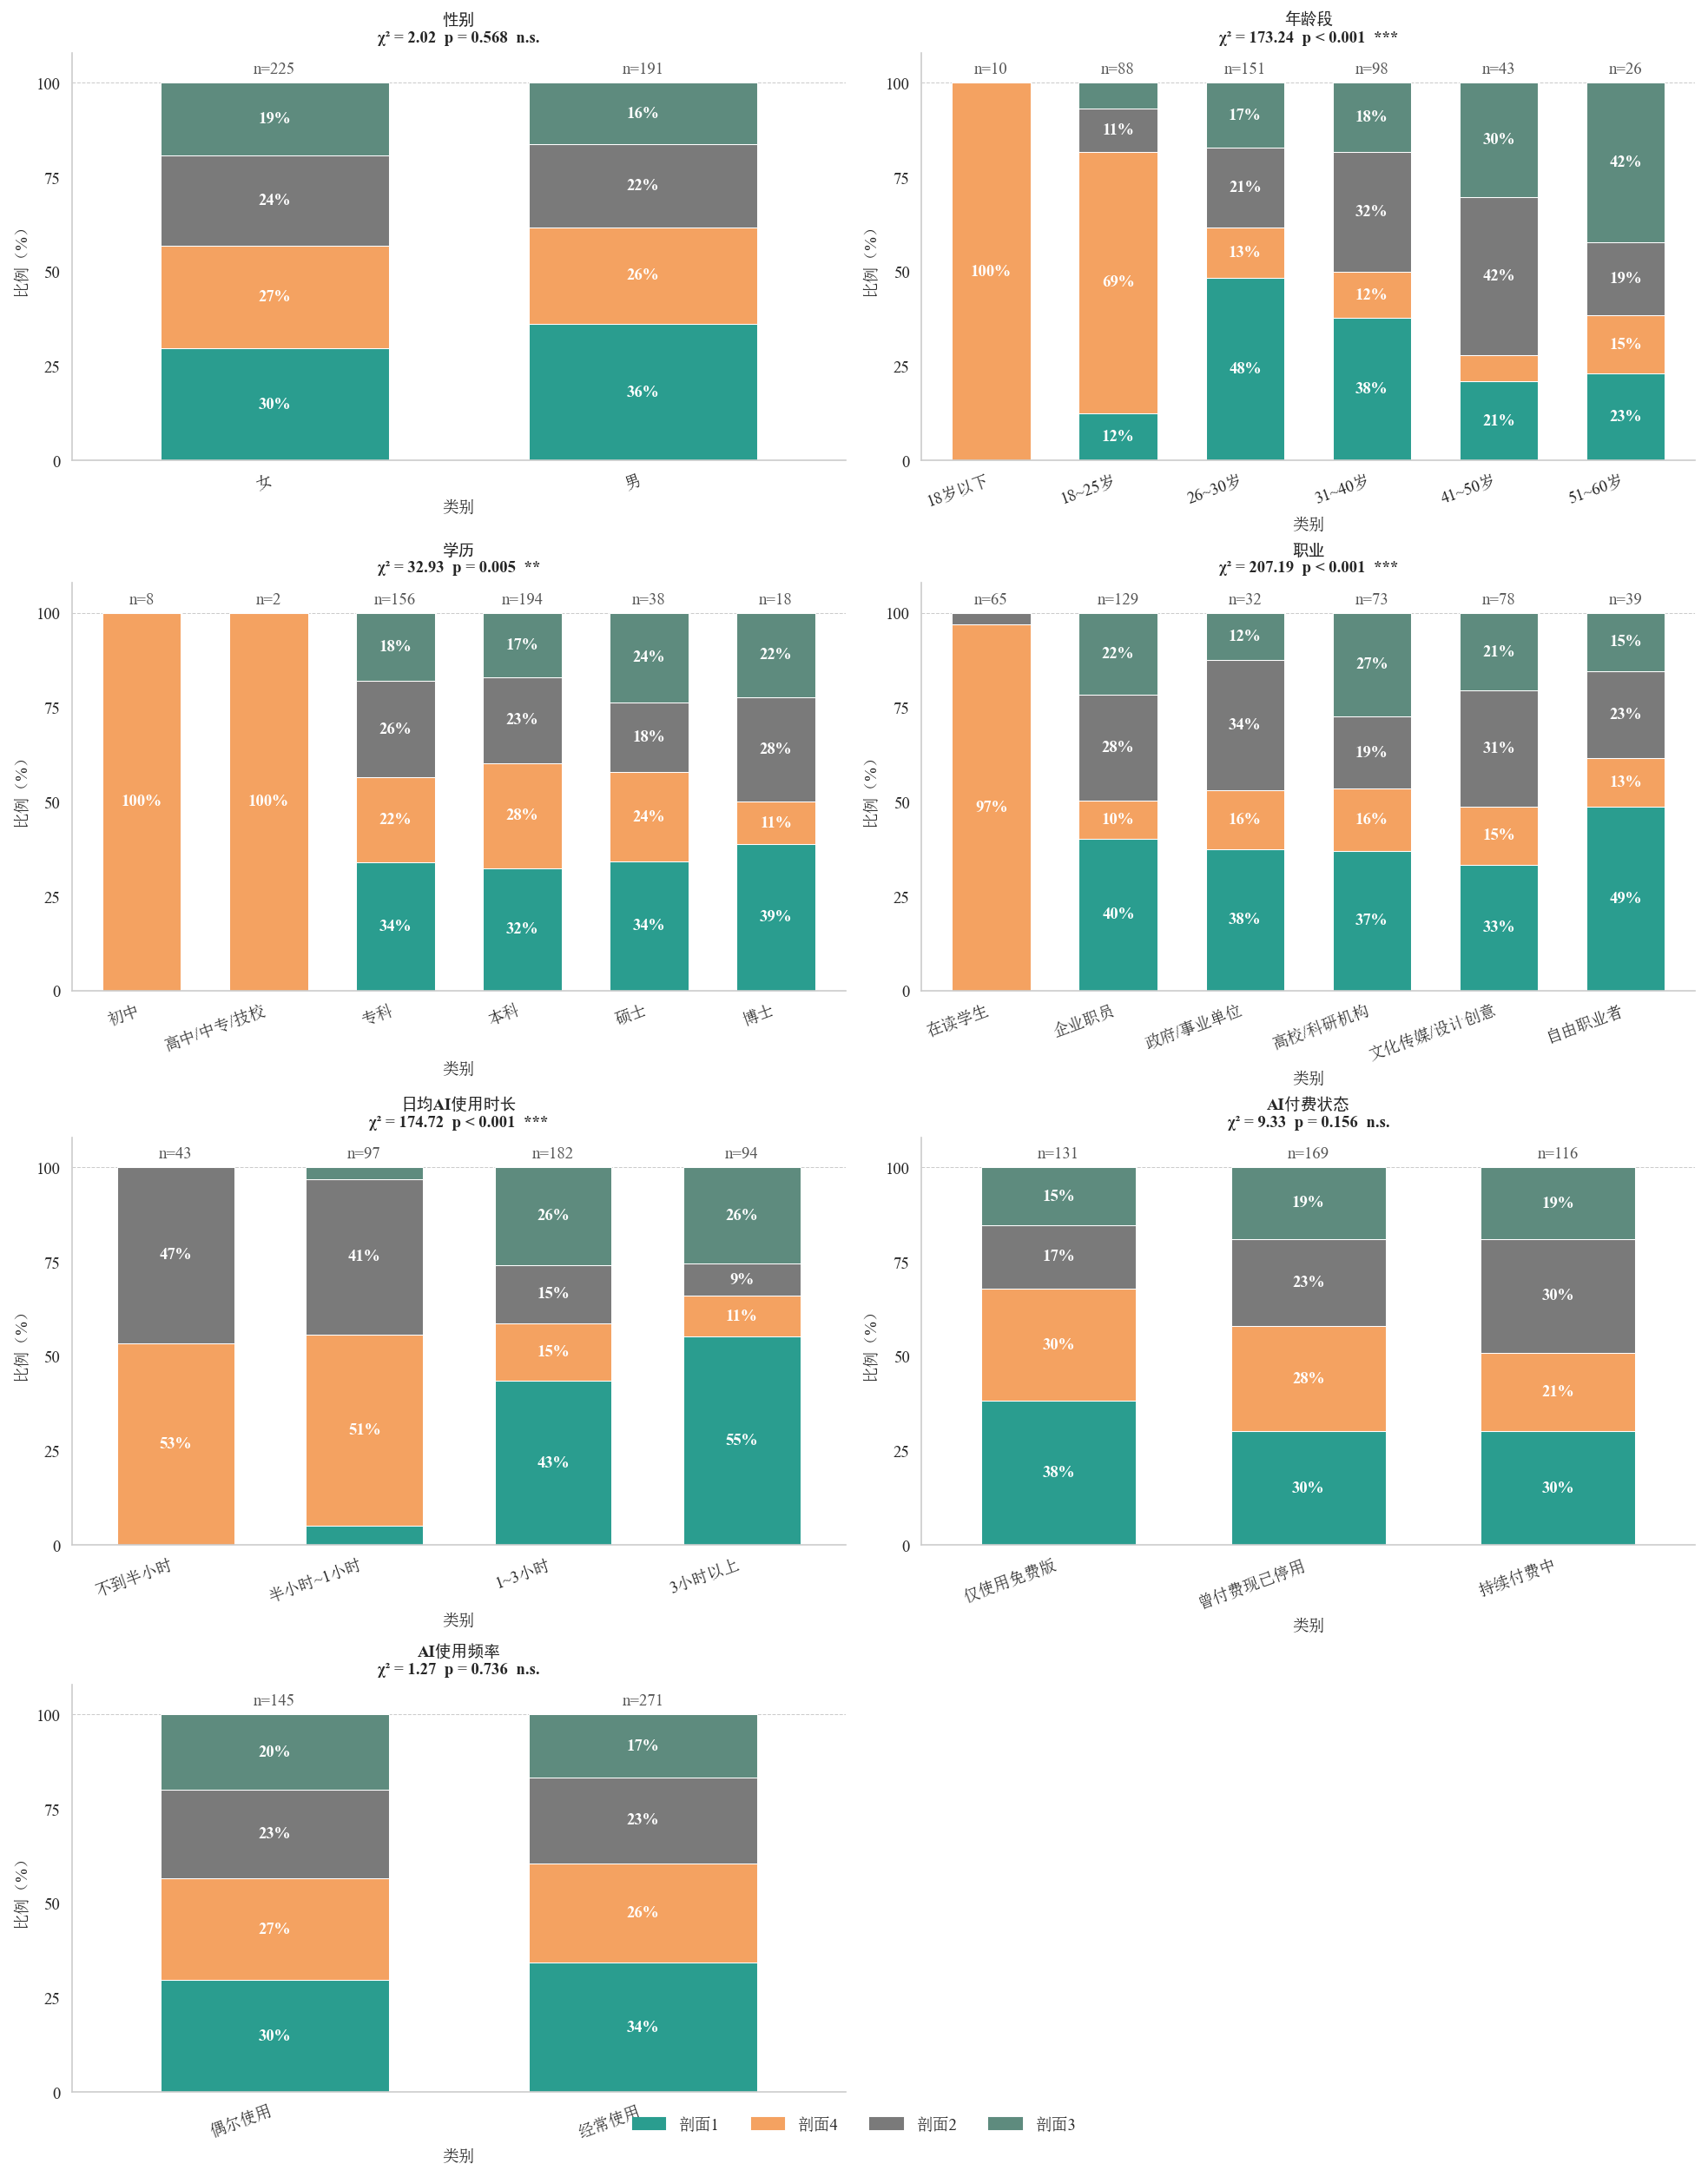

图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\lpa_demographics.png


In [71]:
# 人口统计学交叉分析
DEMO_VARS = ['性别', '年龄段', '学历', '职业', '日均AI使用时长', 'AI付费状态', 'AI使用频率']
demo_raw = sheet1_numeric.loc[lpa_result.index, DEMO_VARS].copy()
demo_df = demo_raw.join(lpa_result[['潜在剖面']])
demo_df['潜在剖面标签'] = demo_df['潜在剖面'].map({k: profile_labels[k] for k in range(optimal_k)})

chi2_rows = []
for variable, meta in VAR_META.items():
    valid = demo_df[['潜在剖面标签', variable]].dropna()
    crosstab = pd.crosstab(valid[variable], valid['潜在剖面标签'])
    if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
        continue
    chi2_value, p_value, dof, expected = chi2_contingency(crosstab)
    n_total = crosstab.values.sum()
    cramer_v = np.sqrt(chi2_value / (n_total * (min(crosstab.shape) - 1)))
    chi2_rows.append({
        '变量': meta['label'],
        'χ²': round(chi2_value, 3),
        '自由度': dof,
        'p_raw': p_value,
        'p值': f'{p_value:.4f}',
        '显著性': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.')),
        "Cramér's V": round(cramer_v, 3),
    })

chi2_table = pd.DataFrame(chi2_rows)
print('人口统计学变量卡方检验：')
display(chi2_table.drop(columns='p_raw').reset_index(drop=True))

for variable, meta in VAR_META.items():
    valid = demo_df[['潜在剖面标签', variable]].dropna().copy()
    valid[variable] = valid[variable].map(meta['cats']).fillna(valid[variable].astype(str))
    count_table = pd.crosstab(valid[variable], valid['潜在剖面标签'], margins=True, margins_name='合计')
    pct_table = pd.crosstab(valid[variable], valid['潜在剖面标签'], normalize='index').mul(100).round(1)
    print(f'交叉表：{meta["label"]}')
    display(count_table)
    display(pct_table.add_suffix('（%）'))

profile_order = [profile_labels[i] for i in sorted_by_size]
profile_colors = 青橙灰配色[:optimal_k]
n_demo = len(VAR_META)
ncols = 2
nrows = (n_demo + ncols - 1) // ncols
fig_demo, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4 + 0.6), constrained_layout=True)
axes_flat = np.atleast_1d(axes).flatten()

for axis_idx, (variable, meta) in enumerate(VAR_META.items()):
    ax = axes_flat[axis_idx]
    valid = demo_df[['潜在剖面标签', variable]].dropna().copy()
    valid[variable] = valid[variable].map(meta['cats']).fillna(valid[variable].astype(str))
    category_order = [meta['cats'][k] for k in sorted(meta['cats']) if meta['cats'][k] in valid[variable].unique()]
    pct = (
        pd.crosstab(valid[variable], valid['潜在剖面标签'], normalize='index')
        .mul(100)
        .reindex(index=category_order, fill_value=0)
        .reindex(columns=profile_order, fill_value=0)
    )

    bottom = np.zeros(len(pct))
    x_ticks = np.arange(len(pct))
    for profile_idx, profile_name in enumerate(profile_order):
        values = pct[profile_name].values
        ax.bar(
            x_ticks,
            values,
            bottom=bottom,
            width=0.62,
            color=profile_colors[profile_idx],
            edgecolor='white',
            linewidth=0.5,
            label=profile_name,
        )
        for x_idx, (value, base) in enumerate(zip(values, bottom)):
            if value >= 8:
                ax.text(x_idx, base + value / 2, f'{value:.0f}%', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
        bottom += values

    for x_idx, category in enumerate(pct.index):
        n_category = int((valid[variable] == category).sum())
        ax.text(x_idx, 101.5, f'n={n_category}', ha='center', va='bottom', fontsize=7, color='#555555')

    ax.set_xlim(-0.55, len(pct) - 0.45)
    ax.set_ylim(0, 108)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(pct.index, fontsize=8.5, rotation=20, ha='right')
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=8)
    ax.axhline(100, color='#CCCCCC', linewidth=0.5, linestyle='--', zorder=0)

    chi_row = chi2_table[chi2_table['变量'] == meta['label']]
    if not chi_row.empty:
        p_value = chi_row['p_raw'].iloc[0]
        p_label = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.3f}'
        设置中文论文图表(
            ax,
            title=f'{meta["label"]}\nχ² = {chi_row["χ²"].iloc[0]:.2f}  {p_label}  {chi_row["显著性"].iloc[0]}',
            xlabel='类别',
            ylabel='比例（%）',
        )
    else:
        设置中文论文图表(ax, title=meta['label'], xlabel='类别', ylabel='比例（%）')

handles = [plt.Rectangle((0, 0), 1, 1, color=profile_colors[i], label=profile_order[i]) for i in range(optimal_k)]
legend = fig_demo.legend(
    handles=handles,
    loc='lower center',
    ncol=optimal_k,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=9,
    frameon=False,
    title=None,
 )
设置图例字体(legend)

for ax in axes_flat[n_demo:]:
    ax.set_visible(False)

应用整图字体(fig_demo)
plt.savefig(OUTPUT_DIR / 'lpa_demographics.png', dpi=300)
plt.show()
print('图已保存：', OUTPUT_DIR / 'lpa_demographics.png')

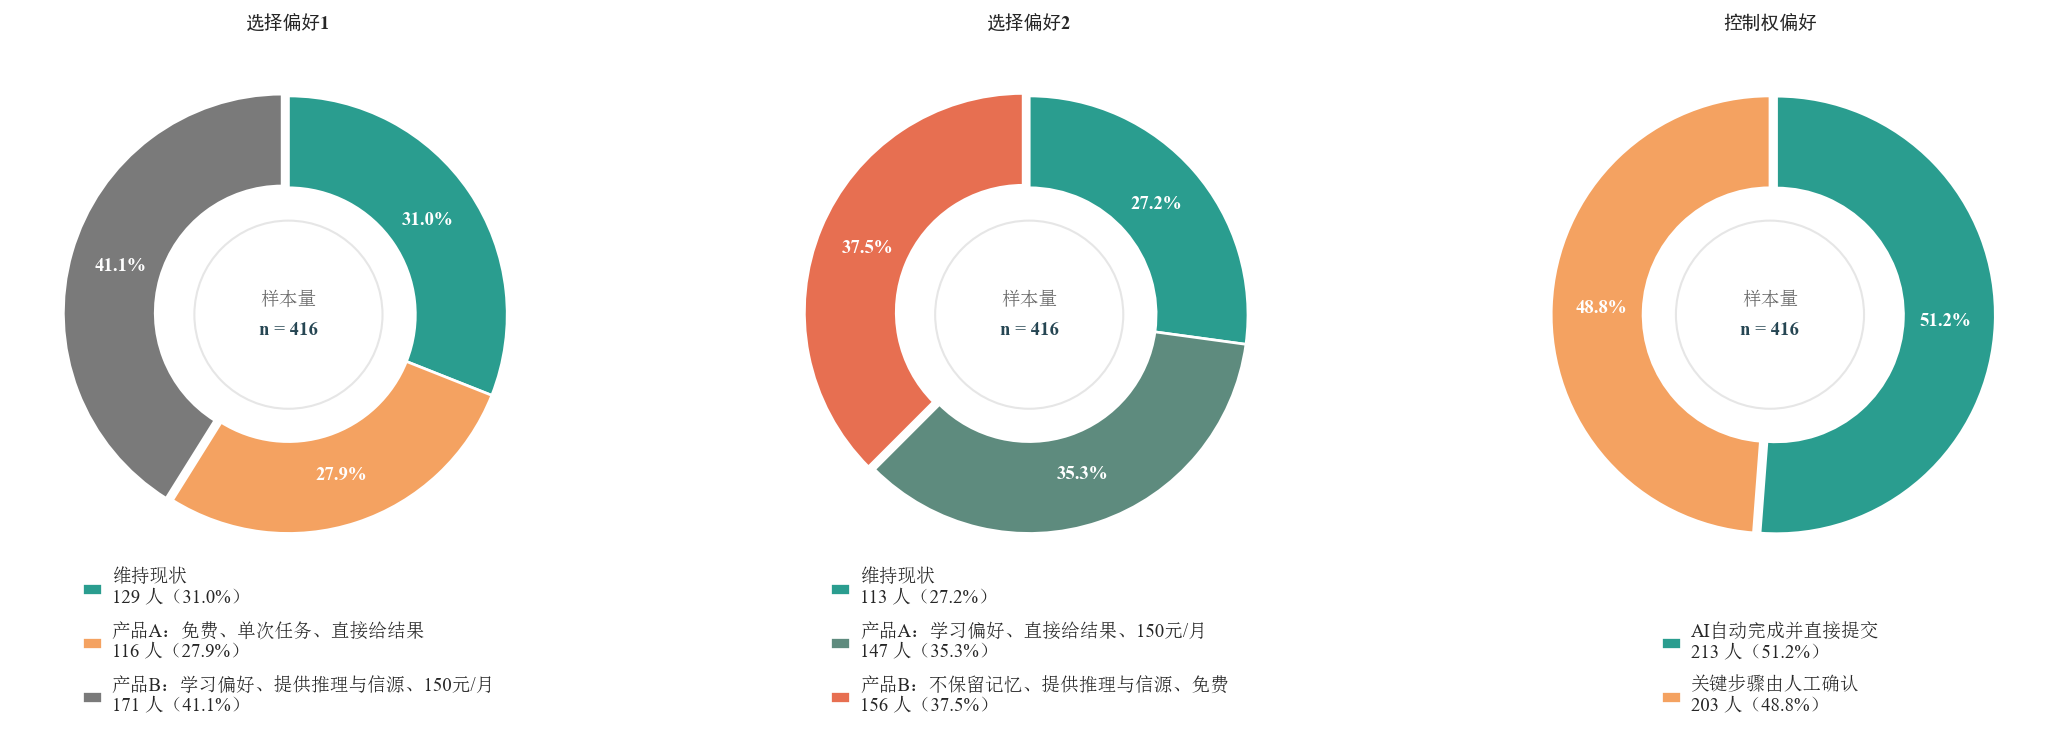

三大核心竞争情境下的产品偏好分布：


,情境,变量,选项,频数,占比（%）
0,选择偏好1,选择偏好1,维持现状,129,31.01
1,选择偏好1,选择偏好1,产品A：免费、单次任务、直接给结果,116,27.88
2,选择偏好1,选择偏好1,产品B：学习偏好、提供推理与信源、150元/月,171,41.11
3,选择偏好2,选择偏好2,维持现状,113,27.16
4,选择偏好2,选择偏好2,产品A：学习偏好、直接给结果、150元/月,147,35.34
5,选择偏好2,选择偏好2,产品B：不保留记忆、提供推理与信源、免费,156,37.50
6,控制权偏好,控制权偏好,AI自动完成并直接提交,213,51.20
7,控制权偏好,控制权偏好,关键步骤由人工确认,203,48.80


图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\choice_preference_pies.png


In [ ]:
# 三大核心竞争情境下的产品偏好描述性统计图
PREFERENCE_LABELS = {
    '选择偏好1': {
        0: '维持现状',
        1: '产品A：免费、单次任务、直接给结果',
        2: '产品B：学习偏好、提供推理与信源、150元/月',
    },
    '选择偏好2': {
        0: '维持现状',
        1: '产品A：学习偏好、直接给结果、150元/月',
        2: '产品B：不保留记忆、提供推理与信源、免费',
    },
    '控制权偏好': {
        0: 'AI自动完成并直接提交',
        1: '关键步骤由人工确认',
    },
}

PREFERENCE_RAW_VALUE_MAPS = {
    '选择偏好1': {
        '都不选，我选择维持现状，不用AI或用现有的其他免费工具': 0,
        '产品A：不保留您的历史记忆，仅做单次任务；直接给结果；完全免费': 1,
        '产品B：深度学习您的偏好，主动提供建议；提供完整的推理步骤与信源；150元/月': 2,
    },
    '选择偏好2': {
        '都不选，我选择维持现状': 0,
        '产品A：深度学习您的偏好；直接给结果；150元/月': 1,
        '产品B：仅做单次任务不留记忆；提供完整的推理步骤与信源；完全免费': 2,
    },
    '控制权偏好': {
        '自动帮您完成排版、修改并直接发送或提交': 0,
        '仅提供草稿，每个关键步骤强制要求您手动点击确认': 1,
        '自动帮您完成排版、修改并直接发送或提交。': 0,
        '仅提供草稿，每个关键步骤强制要求您手动点击确认。': 1,
    },
}

PREFERENCE_TITLES = {
    '选择偏好1': '选择偏好1',
    '选择偏好2': '选择偏好2',
    '控制权偏好': '控制权偏好',
}

PREFERENCE_COLORS = {
    '选择偏好1': [青橙灰配色[0], 青橙灰配色[1], 青橙灰配色[2]],
    '选择偏好2': [青橙灰配色[0], 青橙灰配色[3], 青橙灰配色[4]],
    '控制权偏好': [青橙灰配色[0], 青橙灰配色[1]],
}


def 美化标签(text: str, width: int = 12) -> str:
    return fill(text, width=width, break_long_words=False, break_on_hyphens=False)


def 百分比文本(pct: float) -> str:
    return f'{pct:.1f}%' if pct >= 4 else ''


def 获取偏好编码序列(outcome_col: str) -> pd.Series:
    numeric_series = pd.to_numeric(sheet1_numeric[outcome_col], errors='coerce')
    if numeric_series.notna().sum() > 0:
        return numeric_series

    text_series = sheet1_text[outcome_col].astype(str).str.strip()
    mapped_series = text_series.map(PREFERENCE_RAW_VALUE_MAPS[outcome_col])
    return pd.to_numeric(mapped_series, errors='coerce')


preference_summary_rows = []
fig_pref, axes = plt.subplots(1, 3, figsize=(14.8, 4.8), constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, outcome_col in zip(axes, PREFERENCE_LABELS):
    coded_series = 获取偏好编码序列(outcome_col)
    valid = coded_series.dropna().astype(int)

    label_map = PREFERENCE_LABELS[outcome_col]
    category_order = [code for code in label_map.keys()]
    count_series = valid.value_counts().reindex(category_order, fill_value=0)
    total_n = int(count_series.sum())

    if total_n == 0:
        ax.axis('off')
        ax.text(0.5, 0.5, f'{PREFERENCE_TITLES[outcome_col]}\n无有效数据', ha='center', va='center', fontsize=11, fontproperties=标题字体)
        continue

    pct_series = (count_series / total_n * 100).round(2)

    for code in category_order:
        preference_summary_rows.append({
            '情境': PREFERENCE_TITLES[outcome_col],
            '变量': outcome_col,
            '选项': label_map[code],
            '频数': int(count_series.loc[code]),
            '占比（%）': round(float(pct_series.loc[code]), 2),
        })

    colors = PREFERENCE_COLORS[outcome_col][:len(category_order)]
    explode = [0.03 if value == count_series.max() else 0 for value in count_series]
    wedges, _, autotexts = ax.pie(
        count_series.values,
        labels=None,
        colors=colors,
        startangle=90,
        counterclock=False,
        explode=explode,
        autopct=百分比文本,
        pctdistance=0.77,
        wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 1.3},
        textprops={'color': 'white', 'fontsize': 8.5, 'fontweight': 'bold'},
    )

    centre_circle = plt.Circle((0, 0), 0.43, fc='white', ec='#E6E6E6', lw=1.0)
    ax.add_artist(centre_circle)
    ax.text(0, 0.07, '样本量', ha='center', va='center', fontsize=9, color='#666666', fontproperties=正文字体)
    ax.text(0, -0.07, f'n = {total_n}', ha='center', va='center', fontsize=11, color='#264653', fontproperties=标题字体)

    for autotext in autotexts:
        autotext.set_fontproperties(数字英文字体)
        autotext.set_fontweight('bold')

    legend_labels = [
        f"{美化标签(label_map[code], width=11)}\n{count_series.loc[code]} 人（{pct_series.loc[code]:.1f}%）"
        for code in category_order
    ]
    legend = ax.legend(
        wedges,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.26),
        ncol=1,
        fontsize=8,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.6,
        labelspacing=0.9,
    )
    设置图例字体(legend)
    设置中文论文图表(ax, title=PREFERENCE_TITLES[outcome_col])
    ax.set_aspect('equal')

应用整图字体(fig_pref)
plt.savefig(OUTPUT_DIR / 'choice_preference_pies.png', dpi=300)
plt.show()

choice_preference_summary_df = pd.DataFrame(preference_summary_rows)
print('三大核心竞争情境下的产品偏好分布：')
display(choice_preference_summary_df)
print('图已保存：', OUTPUT_DIR / 'choice_preference_pies.png')

潜在剖面与三类产品偏好的卡方检验：


,情境,变量,样本量,χ²,自由度,p值,Cramér's V,显著性
0,选择偏好1,选择偏好1,416,21.4905,6,0.0015,0.1607,**
1,选择偏好2,选择偏好2,416,17.7861,6,0.0068,0.1462,**
2,控制权偏好,控制权偏好,416,14.3939,3,0.0024,0.1860,**


交叉表：选择偏好1


潜在剖面标签,剖面1,剖面2,剖面3,剖面4
选择偏好1,,,,
维持现状,49,27,28,25
产品A：免费、单次任务、直接给结果,25,35,13,43
产品B：学习偏好、提供推理与信源、150元/月,62,34,33,42


潜在剖面标签,剖面1（%）,剖面2（%）,剖面3（%）,剖面4（%）
选择偏好1,,,,
维持现状,37.98,20.93,21.71,19.38
产品A：免费、单次任务、直接给结果,21.55,30.17,11.21,37.07
产品B：学习偏好、提供推理与信源、150元/月,36.26,19.88,19.30,24.56


...

潜在剖面标签,剖面1,剖面2,剖面3,剖面4
选择偏好2,,,,
维持现状,36,21,26,30
产品A：学习偏好、直接给结果、150元/月,38,41,18,50
产品B：不保留记忆、提供推理与信源、免费,62,34,30,30


潜在剖面标签,剖面1（%）,剖面2（%）,剖面3（%）,剖面4（%）
选择偏好2,,,,
维持现状,31.86,18.58,23.01,26.55
产品A：学习偏好、直接给结果、150元/月,25.85,27.89,12.24,34.01
产品B：不保留记忆、提供推理与信源、免费,39.74,21.79,19.23,19.23


交叉表：控制权偏好


潜在剖面标签,剖面1,剖面2,剖面3,剖面4
控制权偏好,,,,
AI自动完成并直接提交,55,55,34,69
关键步骤由人工确认,81,41,40,41


潜在剖面标签,剖面1（%）,剖面2（%）,剖面3（%）,剖面4（%）
控制权偏好,,,,
AI自动完成并直接提交,25.82,25.82,15.96,32.39
关键步骤由人工确认,39.90,20.20,19.70,20.20


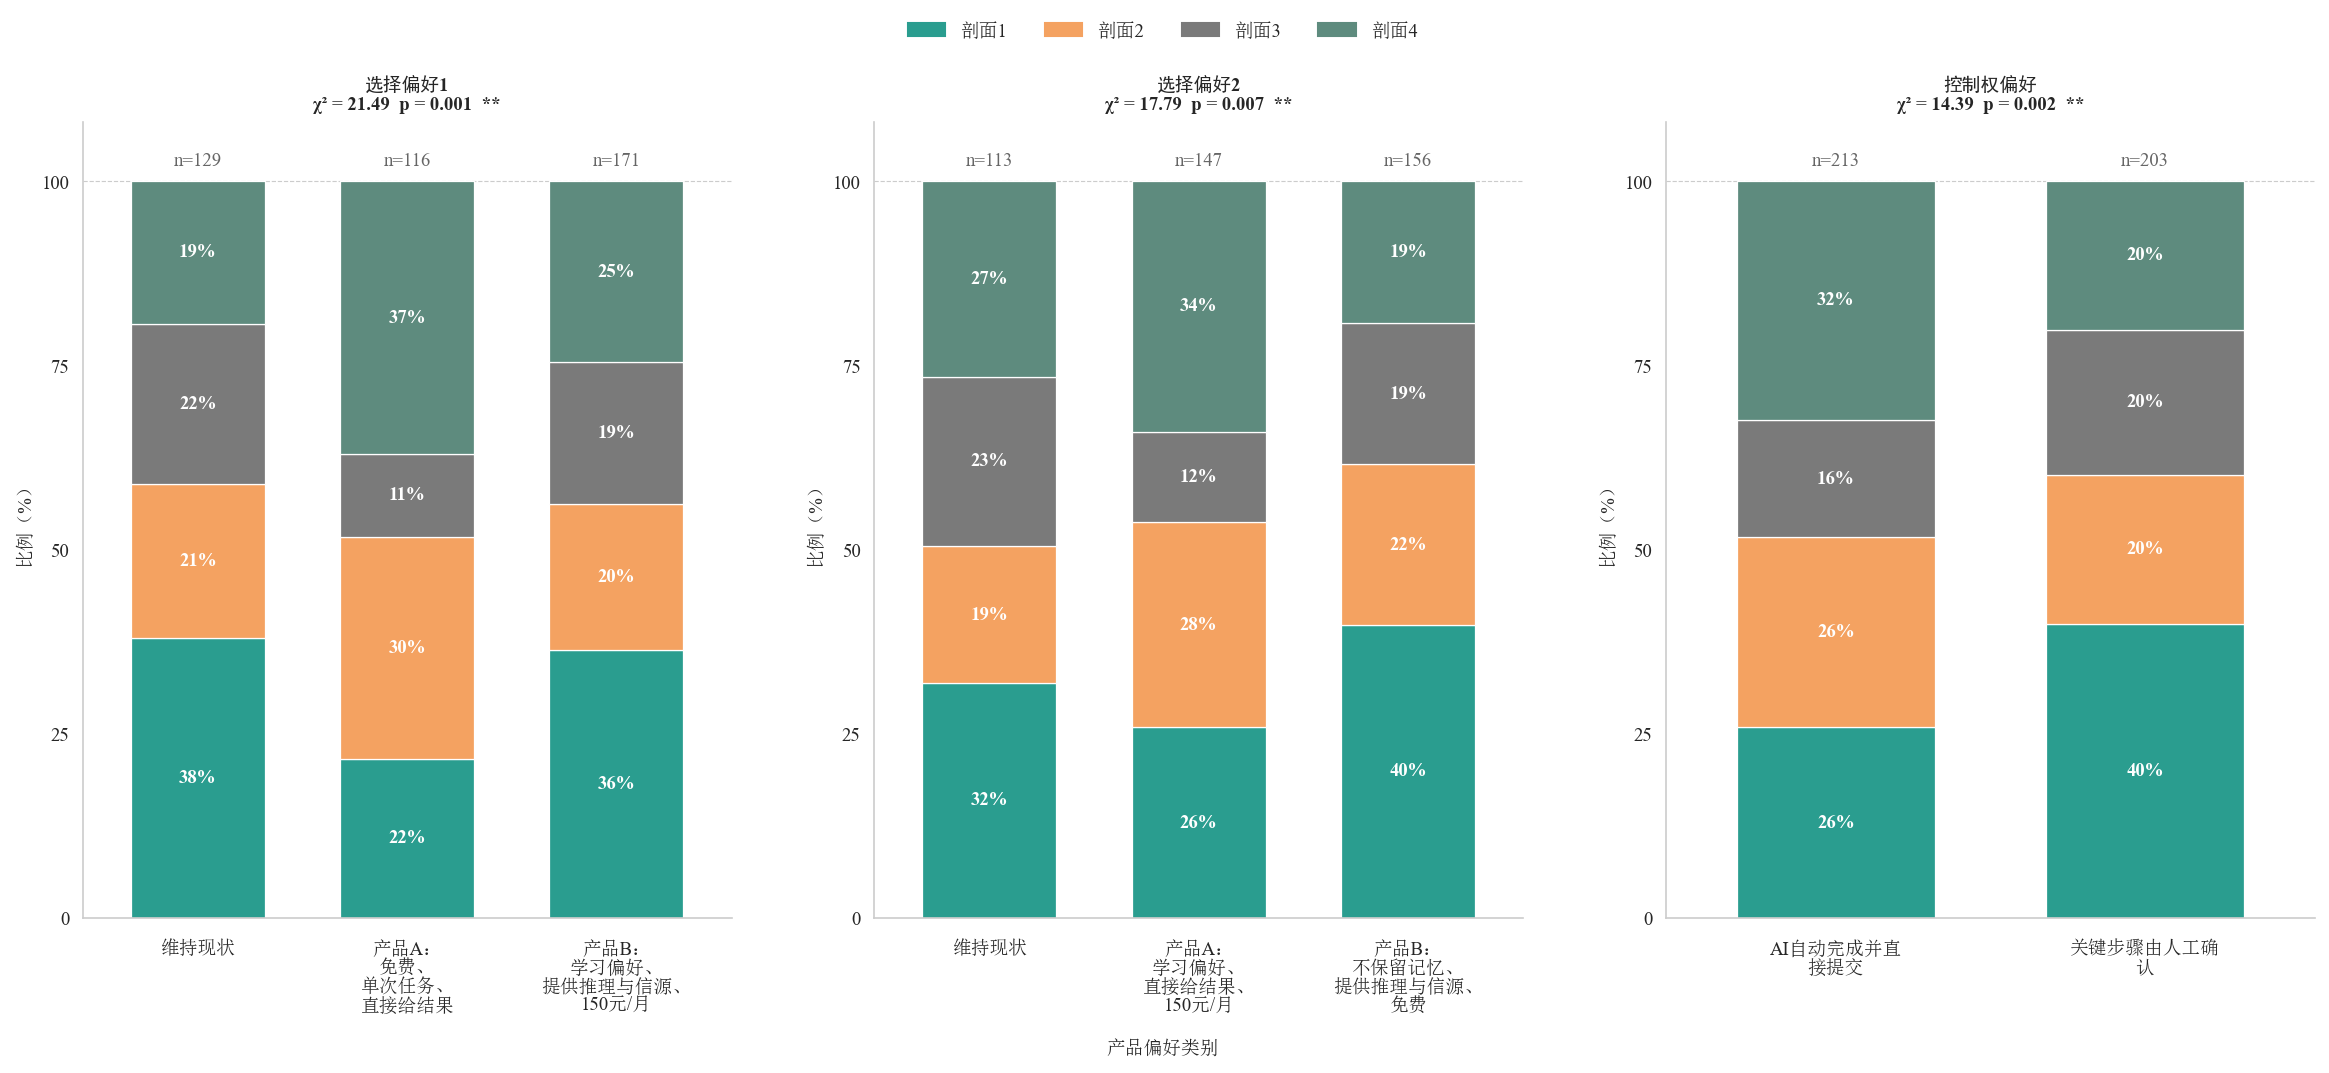

图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\lpa_choice_cross_analysis.png


In [ ]:
# 潜在剖面分类结果与三类产品偏好的卡方检验
PROFILE_CHOICE_VARS = ['选择偏好1', '选择偏好2', '控制权偏好']
PROFILE_CHOICE_TITLES = {
    '选择偏好1': '选择偏好1',
    '选择偏好2': '选择偏好2',
    '控制权偏好': '控制权偏好',
}


def 格式化类别标签(text: str) -> str:
    if len(text) <= 8:
        return text
    if '：' in text:
        prefix, suffix = text.split('：', 1)
        suffix = suffix.replace('、', '、\n').replace('，', '，\n').replace('；', '；\n')
        return f'{prefix}：\n{suffix}'
    return fill(text, width=8, break_long_words=True, break_on_hyphens=False)


profile_choice_df = lpa_result[['潜在剖面']].copy()
profile_choice_df['潜在剖面标签'] = profile_choice_df['潜在剖面'].map({k: profile_labels[k] for k in range(optimal_k)})

for outcome_col in PROFILE_CHOICE_VARS:
    profile_choice_df[outcome_col] = 获取偏好编码序列(outcome_col).reindex(profile_choice_df.index)

choice_profile_chi2_rows = []
choice_profile_tables = {}

for outcome_col in PROFILE_CHOICE_VARS:
    valid = profile_choice_df[['潜在剖面标签', outcome_col]].dropna().copy()
    valid[outcome_col] = valid[outcome_col].astype(int).map(PREFERENCE_LABELS[outcome_col])

    category_order = [
        PREFERENCE_LABELS[outcome_col][k]
        for k in PREFERENCE_LABELS[outcome_col]
        if PREFERENCE_LABELS[outcome_col][k] in valid[outcome_col].unique()
    ]
    profile_order = [profile_labels[k] for k in range(optimal_k)]

    count_table = (
        pd.crosstab(valid[outcome_col], valid['潜在剖面标签'])
        .reindex(index=category_order, columns=profile_order, fill_value=0)
    )
    pct_table = (
        pd.crosstab(valid[outcome_col], valid['潜在剖面标签'], normalize='index')
        .mul(100)
        .reindex(index=category_order, columns=profile_order, fill_value=0)
        .round(2)
    )

    chi2_value, p_value, dof, expected = chi2_contingency(count_table)
    cramer_v = np.sqrt(chi2_value / (count_table.values.sum() * (min(count_table.shape) - 1)))

    choice_profile_chi2_rows.append({
        '情境': PROFILE_CHOICE_TITLES[outcome_col],
        '变量': outcome_col,
        '样本量': int(count_table.values.sum()),
        'χ²': round(chi2_value, 4),
        '自由度': int(dof),
        'p_raw': p_value,
        'p值': '< 0.001' if p_value < 0.001 else f'{p_value:.4f}',
        "Cramér's V": round(cramer_v, 4),
        '显著性': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.')),
    })

    choice_profile_tables[outcome_col] = {
        'count': count_table,
        'pct': pct_table,
    }

choice_profile_chi2_table = pd.DataFrame(choice_profile_chi2_rows)
print('潜在剖面与三类产品偏好的卡方检验：')
display(choice_profile_chi2_table.drop(columns='p_raw').reset_index(drop=True))

for outcome_col in PROFILE_CHOICE_VARS:
    print(f'交叉表：{PROFILE_CHOICE_TITLES[outcome_col]}')
    display(choice_profile_tables[outcome_col]['count'])
    display(choice_profile_tables[outcome_col]['pct'].add_suffix('（%）'))

profile_order = [profile_labels[k] for k in range(optimal_k)]
profile_colors = 青橙灰配色[:optimal_k]
fig_choice_profile, axes = plt.subplots(1, 3, figsize=(19.2, 7.8))
axes = np.atleast_1d(axes)

for ax, outcome_col in zip(axes, PROFILE_CHOICE_VARS):
    pct = choice_profile_tables[outcome_col]['pct']
    count = choice_profile_tables[outcome_col]['count']
    bottom = np.zeros(len(pct))
    x_ticks = np.arange(len(pct))

    for profile_idx, profile_name in enumerate(profile_order):
        values = pct[profile_name].values
        ax.bar(
            x_ticks,
            values,
            bottom=bottom,
            width=0.64,
            color=profile_colors[profile_idx],
            edgecolor='white',
            linewidth=0.6,
            label=profile_name,
        )
        for x_idx, (value, base) in enumerate(zip(values, bottom)):
            if value >= 8:
                ax.text(
                    x_idx,
                    base + value / 2,
                    f'{value:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=7.8,
                    color='white',
                    fontweight='bold',
                )
        bottom += values

    for x_idx, category in enumerate(pct.index):
        n_category = int(count.loc[category].sum())
        ax.text(x_idx, 101.6, f'n={n_category}', ha='center', va='bottom', fontsize=7.2, color='#666666')

    chi_row = choice_profile_chi2_table[choice_profile_chi2_table['变量'] == outcome_col].iloc[0]
    p_label = 'p < 0.001' if chi_row['p_raw'] < 0.001 else f"p = {chi_row['p_raw']:.3f}"
    设置中文论文图表(
        ax,
        title=f"{PROFILE_CHOICE_TITLES[outcome_col]}\nχ² = {chi_row['χ²']:.2f}  {p_label}  {chi_row['显著性']}",
        xlabel=None,
        ylabel='比例（%）',
    )
    ax.set_xlim(-0.55, len(pct) - 0.45)
    ax.set_ylim(0, 108)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(
        [格式化类别标签(label) for label in pct.index],
        fontsize=8,
        linespacing=1.05,
        ha='center',
    )
    ax.tick_params(axis='x', pad=8)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.axhline(100, color='#CCCCCC', linewidth=0.55, linestyle='--', zorder=0)

fig_choice_profile.supxlabel('产品偏好类别', y=0.08, fontproperties=正文字体)
handles = [plt.Rectangle((0, 0), 1, 1, color=profile_colors[i], label=profile_order[i]) for i in range(optimal_k)]
legend = fig_choice_profile.legend(
    handles=handles,
    loc='upper center',
    ncol=optimal_k,
    bbox_to_anchor=(0.5, 0.98),
    fontsize=9,
    frameon=False,
)
设置图例字体(legend)
应用整图字体(fig_choice_profile)
fig_choice_profile.subplots_adjust(bottom=0.20, wspace=0.22)
plt.savefig(OUTPUT_DIR / 'lpa_choice_cross_analysis.png', dpi=300)
plt.show()
print('图已保存：', OUTPUT_DIR / 'lpa_choice_cross_analysis.png')

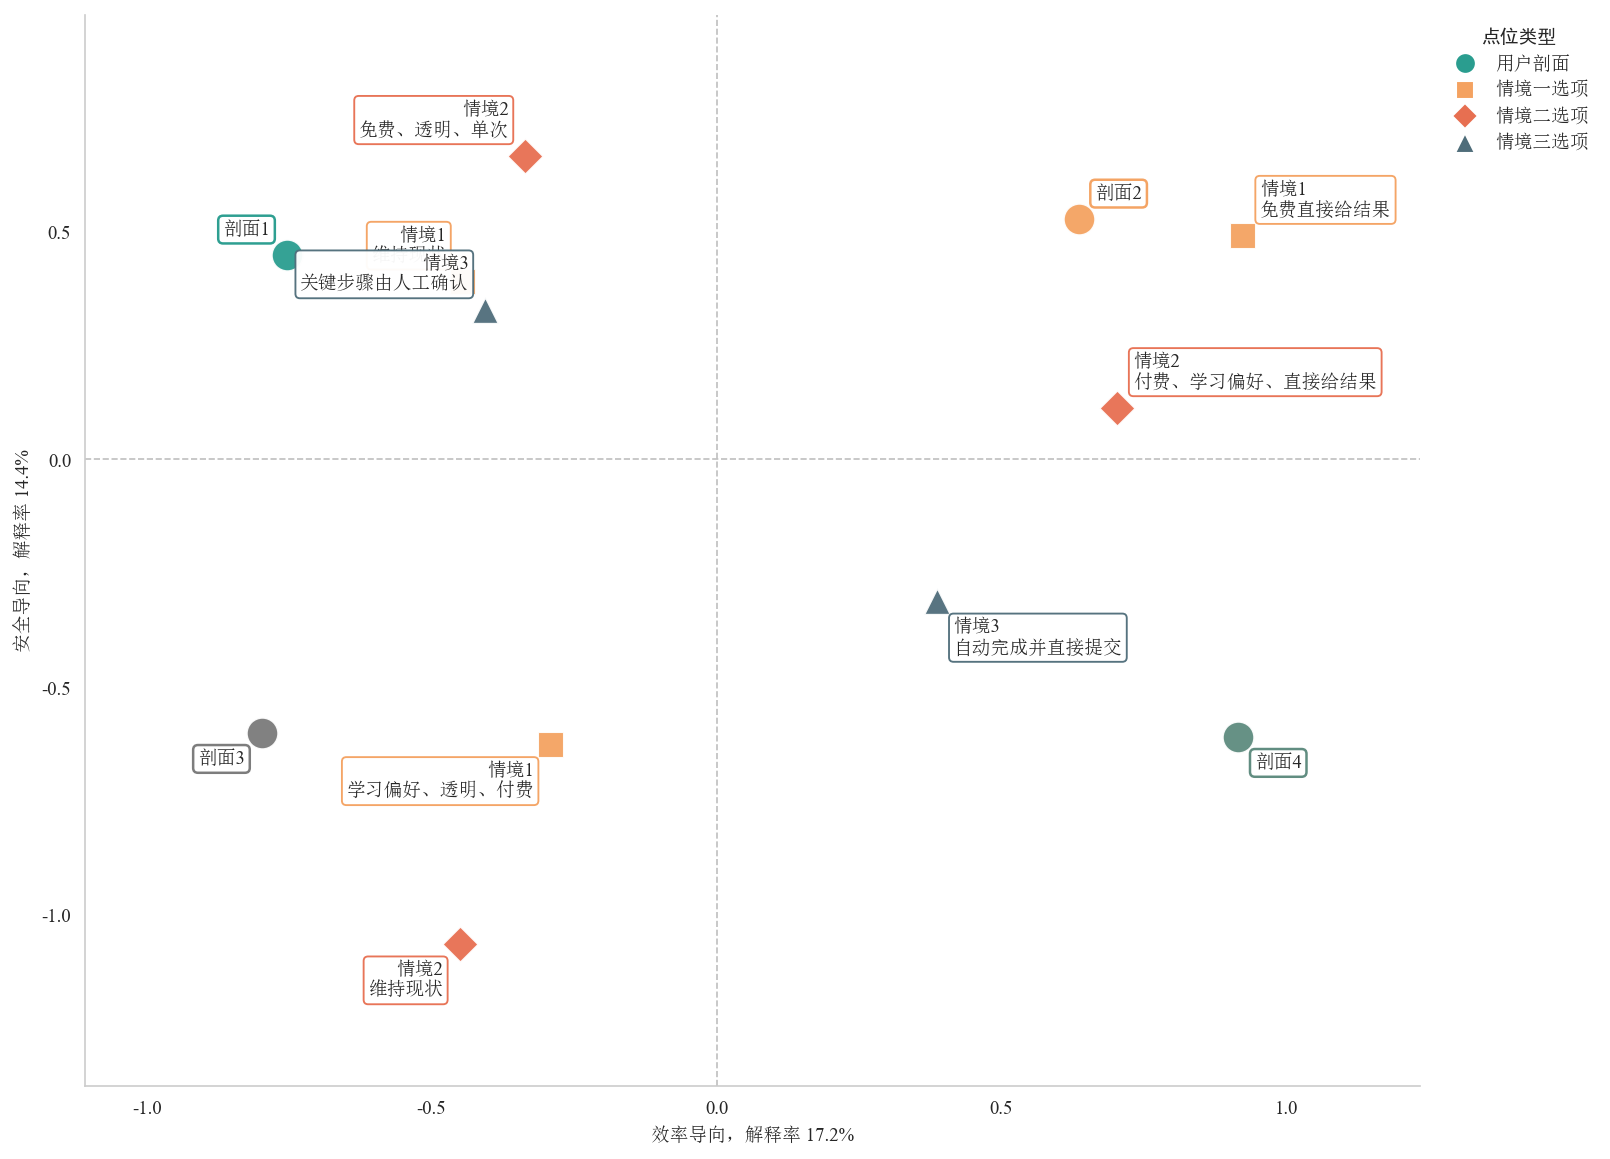

MCA 类别坐标表：


,变量,类别,维度1,维度2,维度1贡献（%）,维度2贡献（%）
0,控制权偏好,AI自动完成并直接提交,0.3866,-0.3117,5.5582,4.3325
1,控制权偏好,关键步骤由人工确认,-0.4057,0.3271,5.8321,4.5460
2,用户剖面,剖面4,0.9154,-0.6099,16.0930,8.5645
3,用户剖面,剖面2,0.6352,0.5272,6.7624,5.5851
4,用户剖面,剖面1,-0.7544,0.4483,13.5125,5.7199
5,用户剖面,剖面3,-0.7984,-0.6012,8.2343,5.5977
6,选择偏好1,产品A：免费、单次任务、直接给结果,0.9242,0.4903,17.2954,5.8378
7,选择偏好1,产品B：学习偏好、提供推理与信源、150元/月,-0.2912,-0.6268,2.5318,14.0644
8,选择偏好1,维持现状,-0.4450,0.3900,4.4592,4.1072
9,选择偏好2,产品A：学习偏好、直接给结果、150元/月,0.7022,0.1121,12.6542,0.3869


图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\profile_choice_mca_map.png
坐标表已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\profile_choice_mca_coordinates.csv


In [ ]:
# 潜在剖面与三类选择题的联合感知图
MCA_PROFILE_VAR = '用户剖面'
MCA_ACTIVE_VARS = [MCA_PROFILE_VAR, '选择偏好1', '选择偏好2', '控制权偏好']
MCA_DIMENSIONS = 2

MCA_SHORT_LABELS = {
    MCA_PROFILE_VAR: {
        '剖面1': '剖面1',
        '剖面2': '剖面2',
        '剖面3': '剖面3',
        '剖面4': '剖面4',
    },
    '选择偏好1': {
        '维持现状': '情境1\n维持现状',
        '产品A：免费、单次任务、直接给结果': '情境1\n免费直接给结果',
        '产品B：学习偏好、提供推理与信源、150元/月': '情境1\n学习偏好、透明、付费',
    },
    '选择偏好2': {
        '维持现状': '情境2\n维持现状',
        '产品A：学习偏好、直接给结果、150元/月': '情境2\n付费、学习偏好、直接给结果',
        '产品B：不保留记忆、提供推理与信源、免费': '情境2\n免费、透明、单次',
    },
    '控制权偏好': {
        'AI自动完成并直接提交': '情境3\n自动完成并直接提交',
        '关键步骤由人工确认': '情境3\n关键步骤由人工确认',
    },
}

MCA_GROUP_STYLES = {
    MCA_PROFILE_VAR: {'marker': 'o', 'size': 230, 'color': None},
    '选择偏好1': {'marker': 's', 'size': 150, 'color': 青橙灰配色[1]},
    '选择偏好2': {'marker': 'D', 'size': 150, 'color': 青橙灰配色[4]},
    '控制权偏好': {'marker': '^', 'size': 165, 'color': 青橙灰配色[6]},
}

profile_color_map = {profile_labels[idx]: 青橙灰配色[idx] for idx in range(optimal_k)}

mca_input_df = pd.DataFrame(index=lpa_result.index)
mca_input_df[MCA_PROFILE_VAR] = lpa_result['潜在剖面'].map({k: profile_labels[k] for k in range(optimal_k)})
for outcome_col in ['选择偏好1', '选择偏好2', '控制权偏好']:
    mca_input_df[outcome_col] = (
        获取偏好编码序列(outcome_col)
        .reindex(lpa_result.index)
        .dropna()
    )
    mca_input_df[outcome_col] = pd.to_numeric(mca_input_df[outcome_col], errors='coerce').map(PREFERENCE_LABELS[outcome_col])

mca_input_df = mca_input_df.dropna().copy()
indicator_df = pd.get_dummies(mca_input_df[MCA_ACTIVE_VARS].astype('category'), prefix_sep='=')
G = indicator_df.astype(float).values
n_obs, n_cat = G.shape
n_vars = len(MCA_ACTIVE_VARS)

P = G / (n_obs * n_vars)
r = P.sum(axis=1)
c = P.sum(axis=0)
expected = np.outer(r, c)
S = ((P - expected) / np.sqrt(r[:, None])) / np.sqrt(c[None, :])

U, singular_values, Vt = np.linalg.svd(S, full_matrices=False)
eigenvalues = singular_values ** 2
explained = eigenvalues / eigenvalues.sum() * 100

col_coords = (Vt.T[:, :MCA_DIMENSIONS] * singular_values[:MCA_DIMENSIONS]) / np.sqrt(c)[:, None]
col_contrib = (c[:, None] * (col_coords ** 2)) / np.maximum(eigenvalues[:MCA_DIMENSIONS], 1e-12) * 100

mca_coords_df = pd.DataFrame(
    col_coords,
    index=indicator_df.columns,
    columns=['维度1', '维度2'],
).reset_index(names='类别键')
mca_coords_df[['变量', '类别']] = mca_coords_df['类别键'].str.split('=', n=1, expand=True)
mca_coords_df['维度1贡献（%）'] = col_contrib[:, 0]
mca_coords_df['维度2贡献（%）'] = col_contrib[:, 1]

coords_lookup = mca_coords_df.set_index(['变量', '类别'])
if coords_lookup.loc[('选择偏好1', '产品B：学习偏好、提供推理与信源、150元/月'), '维度1'] < coords_lookup.loc[('选择偏好1', '维持现状'), '维度1']:
    mca_coords_df['维度1'] *= -1
if coords_lookup.loc[('控制权偏好', '关键步骤由人工确认'), '维度2'] < coords_lookup.loc[('控制权偏好', 'AI自动完成并直接提交'), '维度2']:
    mca_coords_df['维度2'] *= -1

mca_coords_df['显示标签'] = mca_coords_df.apply(
    lambda row: MCA_SHORT_LABELS.get(row['变量'], {}).get(row['类别'], row['类别']),
    axis=1,
)

mca_result_table = (
    mca_coords_df[['变量', '类别', '维度1', '维度2', '维度1贡献（%）', '维度2贡献（%）']]
    .sort_values(['变量', '维度1'], ascending=[True, False])
    .reset_index(drop=True)
)
mca_result_table[['维度1', '维度2', '维度1贡献（%）', '维度2贡献（%）']] = (
    mca_result_table[['维度1', '维度2', '维度1贡献（%）', '维度2贡献（%）']].round(4)
)
mca_result_table.to_csv(OUTPUT_DIR / 'profile_choice_mca_coordinates.csv', index=False, encoding='utf-8-sig')

fig_mca, ax = plt.subplots(figsize=(10.8, 7.8))
ax.axhline(0, color='#BFBFBF', linewidth=0.8, linestyle='--', zorder=0)
ax.axvline(0, color='#BFBFBF', linewidth=0.8, linestyle='--', zorder=0)

for _, row in mca_coords_df.iterrows():
    var_name = row['变量']
    category = row['类别']
    x_val, y_val = row['维度1'], row['维度2']
    style = MCA_GROUP_STYLES[var_name]
    point_color = profile_color_map.get(category, style['color'])

    ax.scatter(
        x_val,
        y_val,
        s=style['size'],
        marker=style['marker'],
        color=point_color,
        edgecolors='white',
        linewidths=1.0,
        alpha=0.95,
        zorder=3 if var_name == MCA_PROFILE_VAR else 2,
    )

    x_offset = 8 if x_val >= 0 else -8
    y_offset = 8 if y_val >= 0 else -8
    ha = 'left' if x_val >= 0 else 'right'
    va = 'bottom' if y_val >= 0 else 'top'

    bbox_style = (
        dict(boxstyle='round,pad=0.24', fc='white', ec=point_color, lw=0.9, alpha=0.96)
        if var_name != MCA_PROFILE_VAR
        else dict(boxstyle='round,pad=0.26', fc='white', ec=point_color, lw=1.2, alpha=0.98)
    )

    ax.annotate(
        row['显示标签'],
        (x_val, y_val),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        ha=ha,
        va=va,
        fontsize=8.5,
        bbox=bbox_style,
        zorder=4,
    )

axis1_label = f"效率导向，解释率 {explained[0]:.1f}%"
axis2_label = f"安全导向，解释率 {explained[1]:.1f}%"
设置中文论文图表(
    ax,
    xlabel=axis1_label,
    ylabel=axis2_label,
)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='用户剖面', markerfacecolor=青橙灰配色[0], markeredgecolor='white', markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='情境一选项', markerfacecolor=青橙灰配色[1], markeredgecolor='white', markersize=9),
    plt.Line2D([0], [0], marker='D', color='w', label='情境二选项', markerfacecolor=青橙灰配色[4], markeredgecolor='white', markersize=9),
    plt.Line2D([0], [0], marker='^', color='w', label='情境三选项', markerfacecolor=青橙灰配色[6], markeredgecolor='white', markersize=10),
]
legend = ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, title='点位类型')
设置图例字体(legend)

padding_x = (mca_coords_df['维度1'].max() - mca_coords_df['维度1'].min()) * 0.18
padding_y = (mca_coords_df['维度2'].max() - mca_coords_df['维度2'].min()) * 0.18
ax.set_xlim(mca_coords_df['维度1'].min() - padding_x, mca_coords_df['维度1'].max() + padding_x)
ax.set_ylim(mca_coords_df['维度2'].min() - padding_y, mca_coords_df['维度2'].max() + padding_y)


应用整图字体(fig_mca)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'profile_choice_mca_map.png', dpi=300)
plt.show()

print('MCA 类别坐标表：')
display(mca_result_table)
print('图已保存：', OUTPUT_DIR / 'profile_choice_mca_map.png')
print('坐标表已保存：', OUTPUT_DIR / 'profile_choice_mca_coordinates.csv')

In [ ]:
# fsQCA 辅助函数与校准后的基础数据
CONSIST_THRESH = ANALYSIS_CONFIG['fsqca_consistency_threshold']
PRI_THRESH = ANALYSIS_CONFIG['fsqca_pri_threshold']
FREQ_THRESH = ANALYSIS_CONFIG['fsqca_frequency_threshold']
NEC_THRESH = CONSIST_THRESH

DIM1_ITEMS = RELIABILITY_DIMENSIONS['依赖度与替代焦虑']
DIM2_ITEMS = RELIABILITY_DIMENSIONS['透明度与控制感']
OUTCOME_ITEMS = RESISTANCE_ITEMS

DIMENSION_VAR_NAMES = {
    '依赖度与替代焦虑': '依赖度与替代焦虑均值',
    '透明度与控制感': '透明度与控制感均值',
}
OUTCOME_VAR = '抵抗意愿'
COND_NAMES = [
    DIMENSION_VAR_NAMES['依赖度与替代焦虑'],
    DIMENSION_VAR_NAMES['透明度与控制感'],
]

FSQCA_LABELS = {
    '依赖度与替代焦虑均值': '依赖度与替代焦虑',
    '透明度与控制感均值': '透明度与控制感',
    '日均AI使用时长': '日均AI使用时长',
    'AI使用频率': 'AI使用频率',
    '年龄段': '年龄段',
    '性别': '性别',
    '学历': '学历',
    '职业': '职业',
    'AI付费状态': 'AI付费状态',
    '抵抗意愿': '抵抗意愿',
}

full_df = sheet1_numeric.copy()
full_df[DIMENSION_VAR_NAMES['依赖度与替代焦虑']] = full_df[DIM1_ITEMS].mean(axis=1)
full_df[DIMENSION_VAR_NAMES['透明度与控制感']] = full_df[DIM2_ITEMS].mean(axis=1)
full_df[OUTCOME_VAR] = full_df[OUTCOME_ITEMS].mean(axis=1)
fsqca_raw = full_df.loc[lpa_result.index, COND_NAMES + [OUTCOME_VAR]].dropna().copy()


def calibrate_logistic(series: pd.Series, p_low: float = 0.05, p_mid: float = 0.50, p_high: float = 0.95) -> pd.Series:
    z_low = series.quantile(p_low)
    z_mid = series.quantile(p_mid)
    z_high = series.quantile(p_high)
    spread = z_high - z_low
    if spread == 0:
        spread = 1e-9
    odds = np.exp((series - z_mid) / spread * np.log(19))
    membership = odds / (1.0 + odds)
    return membership.clip(1e-6, 1 - 1e-6)


def consistency(Zi: np.ndarray, Yi: np.ndarray) -> float:
    denom = Zi.sum()
    return np.minimum(Zi, Yi).sum() / denom if denom > 0 else np.nan


def coverage(Zi: np.ndarray, Yi: np.ndarray) -> float:
    denom = Yi.sum()
    return np.minimum(Zi, Yi).sum() / denom if denom > 0 else np.nan


def pri(Zi: np.ndarray, Yi: np.ndarray) -> float:
    tri = np.minimum.reduce([Zi, Yi, 1 - Yi]).sum()
    numer = np.minimum(Zi, Yi).sum() - tri
    denom = Zi.sum() - tri
    return numer / denom if denom > 0 else np.nan


def consistency_nec(Zi: np.ndarray, Yi: np.ndarray) -> float:
    denom = Yi.sum()
    return np.minimum(Zi, Yi).sum() / denom if denom > 0 else np.nan


def coverage_nec(Zi: np.ndarray, Yi: np.ndarray) -> float:
    denom = Zi.sum()
    return np.minimum(Zi, Yi).sum() / denom if denom > 0 else np.nan


def format_condition_base_name(name: str) -> str:
    return FSQCA_LABELS.get(name, name.replace('_', ' ').title())


def format_condition_name(name: str, is_negated: bool | None = None) -> str:
    if is_negated is None and name.startswith('~'):
        name = name[1:]
        is_negated = True
    if is_negated is None:
        return format_condition_base_name(name)
    prefix = '反向' if is_negated else '正向'
    return f'{prefix}{format_condition_base_name(name)}'


def wrap_condition_label(name: str, width: int = 12) -> str:
    return '\n'.join(textwrap.wrap(format_condition_base_name(name), width=width))


def fmt_config(config: tuple[int, ...], names: list[str]) -> str:
    return ' * '.join(
        format_condition_name(name, value == 0)
        if value == 0 else format_condition_name(name, False)
        for value, name in zip(config, names)
    )


def combine_implicant(a: tuple[str, ...], b: tuple[str, ...]) -> tuple[str, ...] | None:
    diff_positions = [idx for idx, (x, y) in enumerate(zip(a, b)) if x != y]
    if len(diff_positions) != 1:
        return None
    combined = list(a)
    combined[diff_positions[0]] = '_'
    return tuple(combined)


def quine_mccluskey(minterms: list[tuple[str, ...]]) -> list[tuple[str, ...]]:
    if not minterms:
        return []
    current = set(minterms)
    prime_implicants = set()

    while current:
        next_group = set()
        used = set()
        items = list(current)
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                combined = combine_implicant(items[i], items[j])
                if combined is not None:
                    next_group.add(combined)
                    used.add(items[i])
                    used.add(items[j])
        prime_implicants |= current - used
        current = next_group

    return list(prime_implicants)


def essential_cover(prime_implicants: list[tuple[str, ...]], minterms: list[tuple[str, ...]]) -> list[tuple[str, ...]]:
    def covers(pi: tuple[str, ...], mt: tuple[str, ...]) -> bool:
        return all(p == '_' or p == m for p, m in zip(pi, mt))

    uncovered = set(minterms)
    selected = []

    for mt in list(uncovered):
        coverers = [pi for pi in prime_implicants if covers(pi, mt)]
        if len(coverers) == 1 and coverers[0] not in selected:
            selected.append(coverers[0])

    for pi in selected:
        uncovered -= {mt for mt in uncovered if covers(pi, mt)}

    while uncovered:
        best = max(prime_implicants, key=lambda pi: sum(covers(pi, mt) for mt in uncovered))
        if best not in selected:
            selected.append(best)
        uncovered -= {mt for mt in uncovered if covers(best, mt)}

    return selected


def pi_to_str(pi: tuple[str, ...], names: list[str]) -> str:
    parts = []
    for value, name in zip(pi, names):
        if value == '1':
            parts.append(format_condition_name(name, False))
        elif value == '0':
            parts.append(format_condition_name(name, True))
    return ' * '.join(parts) if parts else '恒成立'


def get_easy_remainders(remainders: list[tuple[str, ...]], minterms: list[tuple[str, ...]], theory_direction: dict[int, str]) -> list[tuple[str, ...]]:
    easy = []
    for remainder in remainders:
        for mt in minterms:
            diff_positions = [idx for idx in range(len(remainder)) if remainder[idx] != mt[idx]]
            if all(remainder[idx] == theory_direction.get(idx, remainder[idx]) for idx in diff_positions):
                easy.append(remainder)
                break
    return list(set(easy))


def solve_three(minterms_1: list[tuple[str, ...]], remainders: list[tuple[str, ...]], theory_direction: dict[int, str]):
    conservative_pis = quine_mccluskey(minterms_1)
    conservative_sol = essential_cover(conservative_pis, minterms_1)

    if remainders:
        parsimonious_pis = quine_mccluskey(list(set(minterms_1) | set(remainders)))
        parsimonious_sol = essential_cover(parsimonious_pis, minterms_1)
    else:
        parsimonious_sol = conservative_sol

    easy_remainders = get_easy_remainders(remainders, minterms_1, theory_direction)
    if easy_remainders:
        intermediate_pis = quine_mccluskey(list(set(minterms_1) | set(easy_remainders)))
        intermediate_sol = essential_cover(intermediate_pis, minterms_1)
    else:
        intermediate_sol = conservative_sol

    return conservative_sol, parsimonious_sol, intermediate_sol


def solution_membership(pi: tuple[str, ...], calibrated_df: pd.DataFrame, condition_names: list[str]) -> np.ndarray:
    parts = []
    for idx, value in enumerate(pi):
        raw = calibrated_df[condition_names[idx]].values
        if value == '1':
            parts.append(raw)
        elif value == '0':
            parts.append(1 - raw)
    return np.minimum.reduce(parts) if parts else np.ones(len(calibrated_df))


def solution_metrics(solution_pis: list[tuple[str, ...]], Yi: np.ndarray, calibrated_df: pd.DataFrame, condition_names: list[str]):
    rows = []
    pi_memberships = [solution_membership(pi, calibrated_df, condition_names) for pi in solution_pis]
    union_membership = np.maximum.reduce(pi_memberships) if pi_memberships else np.zeros(len(calibrated_df))

    for pi, membership in zip(solution_pis, pi_memberships):
        other_memberships = [m for m in pi_memberships if not np.array_equal(m, membership)]
        if other_memberships:
            others_union = np.maximum.reduce(other_memberships)
            unique_coverage = (np.minimum(membership, Yi).sum() - np.minimum(others_union, np.minimum(membership, Yi)).sum()) / Yi.sum()
        else:
            unique_coverage = coverage(membership, Yi)
        rows.append({
            '组态路径': pi_to_str(pi, condition_names),
            '原始覆盖度': round(coverage(membership, Yi), 4),
            '独特覆盖度': round(unique_coverage, 4),
            '一致性': round(consistency(membership, Yi), 4),
            'PRI': round(pri(membership, Yi), 4),
        })

    overall_consistency = round(consistency(union_membership, Yi), 4) if pi_memberships else np.nan
    overall_coverage = round(coverage(union_membership, Yi), 4) if pi_memberships else np.nan
    return pd.DataFrame(rows), overall_consistency, overall_coverage


def plot_necessity_scatter(condition_specs: list[dict], outcome: np.ndarray, filename: str):
    fig, axes = plt.subplots(1, len(condition_specs), figsize=(5.2 * len(condition_specs), 4.6), constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, spec in zip(axes, condition_specs):
        x_vals = spec['membership']
        jitter = np.random.default_rng(42).uniform(-0.008, 0.008, size=len(x_vals))
        ax.scatter(
            x_vals + jitter,
            outcome + jitter,
            c=outcome,
            cmap=plt.cm.PuBuGn,
            s=24,
            alpha=0.6,
            linewidths=0,
            vmin=0,
            vmax=1,
        )
        ax.plot([0, 1], [0, 1], color='#666666', linewidth=1.0, linestyle='--')
        ax.axvline(0.5, color='#CCCCCC', linewidth=0.8, linestyle=':')
        ax.axhline(0.5, color='#CCCCCC', linewidth=0.8, linestyle=':')
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.03, 1.03)
        设置中文论文图表(ax, title=spec['title'], xlabel='条件隶属度', ylabel='结果隶属度')
        ax.text(
            0.03, 0.97,
            f"一致性 = {spec['consistency']:.3f}\n覆盖度 = {spec['coverage']:.3f}",
            transform=ax.transAxes,
            va='top',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#CCCCCC', lw=0.6),
        )
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    应用整图字体(fig)
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_solution_scatter(
    solution_pis: list[tuple[str, ...]],
    calibrated_df: pd.DataFrame,
    condition_names: list[str],
    outcome: np.ndarray,
    filename: str,
    layout: str = 'horizontal',
):
    n_terms = max(len(solution_pis), 1)
    if layout == 'vertical':
        nrows, ncols = n_terms, 1
        figsize = (6.6, max(4.8, 4.4 * n_terms))
    else:
        nrows, ncols = 1, n_terms
        figsize = (max(5.5, 5.5 * n_terms), 4.8)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).flatten()

    if not solution_pis:
        axes[0].text(0.5, 0.5, '无可展示的路径', ha='center', va='center', fontsize=11)
        axes[0].axis('off')
    else:
        for ax, pi in zip(axes, solution_pis):
            membership = solution_membership(pi, calibrated_df, condition_names)
            jitter = np.random.default_rng(42).uniform(-0.008, 0.008, size=len(membership))
            sc = ax.scatter(
                membership + jitter,
                outcome + jitter,
                c=outcome,
                cmap=plt.cm.YlGnBu,
                alpha=0.58,
                s=20,
                linewidths=0,
                vmin=0,
                vmax=1,
            )
            ax.plot([0, 1], [0, 1], color='#888888', linewidth=0.9, linestyle='--')
            ax.axvline(0.5, color='#CCCCCC', linewidth=0.6, linestyle=':')
            ax.axhline(0.5, color='#CCCCCC', linewidth=0.6, linestyle=':')
            ax.set_xlim(-0.04, 1.04)
            ax.set_ylim(-0.04, 1.04)
            设置中文论文图表(ax, title=pi_to_str(pi, condition_names), xlabel='路径隶属度', ylabel='结果隶属度')
            ax.text(
                0.03, 0.97,
                f'一致性 = {consistency(membership, outcome):.3f}\n覆盖度 = {coverage(membership, outcome):.3f}\nPRI = {pri(membership, outcome):.3f}',
                transform=ax.transAxes,
                va='top',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#CCCCCC', lw=0.6),
            )
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
            设置色条字体(cbar, '结果隶属度')

        for ax in axes[len(solution_pis):]:
            ax.set_visible(False)

    应用整图字体(fig)
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_solution_path_chart(path_rows: list[dict], filename: str):
    if not path_rows:
        return

    n_rows = len(path_rows)
    condition_names = []
    for row in path_rows:
        for condition in row['condition_names']:
            if condition not in condition_names:
                condition_names.append(condition)

    metric_x = {
        '一致性': len(condition_names) + 1.2,
        '覆盖度': len(condition_names) + 2.9,
        'PRI': len(condition_names) + 4.2,
    }
    fig_width = max(17, 1.35 * len(condition_names) + 9.5)
    fig_height = max(6.2, 0.95 * n_rows + 2.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    ax.set_xlim(-7.6, len(condition_names) + 5.4)
    ax.set_ylim(-0.9, n_rows + 0.9)

    for row_idx, row in enumerate(path_rows):
        y = n_rows - 1 - row_idx
        ax.text(-1.4, y, row['row_label'], ha='right', va='center', fontsize=10, fontweight='bold')
        pi = row['pi']

        for col_idx, condition in enumerate(condition_names):
            ax.scatter(col_idx, y, s=220, facecolors='none', edgecolors='#D9D9D9', linewidths=1.0, zorder=1)
            if condition in row['condition_names']:
                condition_idx = row['condition_names'].index(condition)
                state = pi[condition_idx]
                if state == '1':
                    ax.scatter(col_idx, y, s=220, facecolors=青橙灰配色[0], edgecolors=青橙灰配色[0], linewidths=1.2, zorder=2)
                elif state == '0':
                    ax.scatter(col_idx, y, s=220, facecolors='white', edgecolors=青橙灰配色[2], linewidths=1.8, zorder=2)
                    ax.text(col_idx, y, '×', ha='center', va='center', fontsize=11, color=青橙灰配色[2], fontweight='bold', zorder=3)
                else:
                    ax.text(col_idx, y, '–', ha='center', va='center', fontsize=12, color='#777777', zorder=3)
            else:
                ax.text(col_idx, y, '–', ha='center', va='center', fontsize=12, color='#777777', zorder=3)

        ax.text(metric_x['一致性'], y, f"{row['consistency']:.3f}", va='center', ha='center', fontsize=10)
        ax.text(metric_x['覆盖度'], y, f"{row['coverage']:.3f}", va='center', ha='center', fontsize=10)
        ax.text(metric_x['PRI'], y, f"{row['pri']:.3f}", va='center', ha='center', fontsize=10)

    for x_idx, condition in enumerate(condition_names):
        ax.text(
            x_idx,
            n_rows + 0.15,
            wrap_condition_label(condition, width=12),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
        )

    for metric_name, x_pos in metric_x.items():
        ax.text(x_pos, n_rows + 0.25, metric_name, ha='center', va='bottom', fontsize=9.5, fontweight='bold')

    legend_y = -0.55
    ax.scatter(-0.1, legend_y, s=190, facecolors=青橙灰配色[0], edgecolors=青橙灰配色[0])
    ax.text(0.18, legend_y, '正向', va='center', fontsize=8.5)
    ax.scatter(1.15, legend_y, s=190, facecolors='white', edgecolors=青橙灰配色[2], linewidths=1.6)
    ax.text(1.15, legend_y, '×', ha='center', va='center', fontsize=10, color=青橙灰配色[2], fontweight='bold')
    ax.text(1.45, legend_y, '反向', va='center', fontsize=8.5)
    ax.text(2.45, legend_y, '–  无关', va='center', fontsize=8.5, color='#777777')

    ax.axis('off')
    应用整图字体(fig)
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


fsqca_cal = pd.DataFrame(index=fsqca_raw.index)
anchor_rows = []
for column in COND_NAMES + [OUTCOME_VAR]:
    fsqca_cal[column] = calibrate_logistic(fsqca_raw[column])
    series = fsqca_raw[column]
    anchor_rows.append({
        '变量': format_condition_base_name(column),
        'z_0.05（完全非隶属）': round(series.quantile(0.05), 4),
        'z_0.50（交叉点）': round(series.quantile(0.50), 4),
        'z_0.95（完全隶属）': round(series.quantile(0.95), 4),
    })

calibration_anchor_df = pd.DataFrame(anchor_rows)
print('fsQCA 样本量：', len(fsqca_raw))
display(calibration_anchor_df)

fsQCA 样本量： 416


,变量,z_0.05（完全非隶属）,z_0.50（交叉点）,z_0.95（完全隶属）
0,依赖度与替代焦虑,1.875,4.875,6.25
1,透明度与控制感,1.750,4.750,6.50
2,抵抗意愿,1.500,4.500,7.00


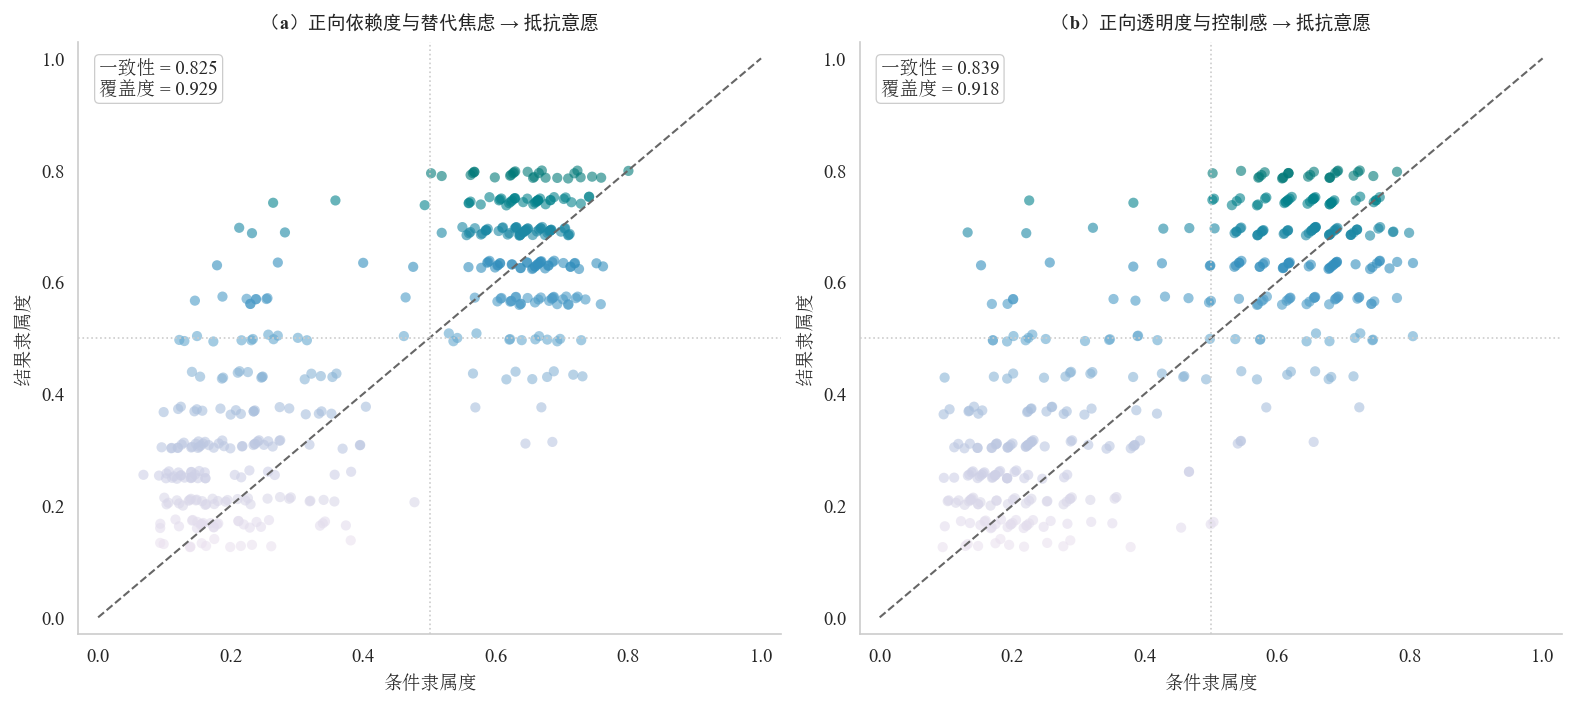

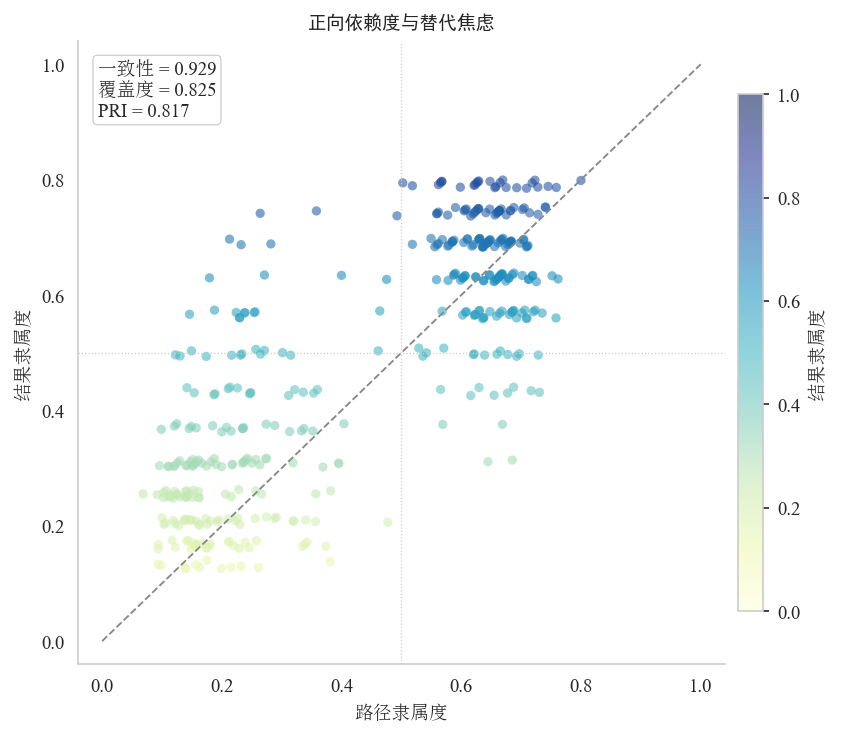

真值表：


,组态表达式,样本量,一致性,PRI,原始覆盖度,结果（1=属于）
0,反向依赖度与替代焦虑 * 反向透明度与控制感,201,0.4103,0.0407,0.6424,0
1,反向依赖度与替代焦虑 * 正向透明度与控制感,8,0.8675,0.5803,0.5859,0
2,正向依赖度与替代焦虑 * 反向透明度与控制感,14,0.9723,0.9076,0.5679,1
3,正向依赖度与替代焦虑 * 正向透明度与控制感,193,0.9514,0.8944,0.7809,1


正向结果解：


,组态路径,一致性,原始覆盖度,PRI
0,正向依赖度与替代焦虑,0.9292,0.8252,0.8174


整体解的一致性 = 0.9292；整体解的原始覆盖度 = 0.8252
负向结果（反向抵抗意愿）满足阈值的组态：


,组态表达式,样本量,一致性,PRI,原始覆盖度
0,反向依赖度与替代焦虑 * 反向透明度与控制感,201,0.8872,0.8165,0.9059


图已保存：
c:\Users\Administrator\Desktop\正大杯\code\outputs\fsqca_necessity_scatter.png
c:\Users\Administrator\Desktop\正大杯\code\outputs\fsqca_solution_scatter.png


In [69]:
# fsQCA 基础模型
Yi_full = fsqca_cal[OUTCOME_VAR].values
binary_df = (fsqca_cal[COND_NAMES] > 0.5).astype(int)

truth_rows = []
for config in __import__('itertools').product([0, 1], repeat=len(COND_NAMES)):
    mask = np.ones(len(binary_df), dtype=bool)
    for idx, value in enumerate(config):
        mask &= (binary_df.iloc[:, idx].values == value)

    n_cases = int(mask.sum())
    if n_cases == 0:
        truth_rows.append({
            'config': config,
            'n': 0,
            'consist': np.nan,
            'PRI': np.nan,
            'raw_cov': np.nan,
            'outcome': pd.NA,
        })
        continue

    subset_parts = []
    full_parts = []
    for idx, value in enumerate(config):
        subset_membership = fsqca_cal[COND_NAMES[idx]].values[mask]
        full_membership = fsqca_cal[COND_NAMES[idx]].values
        subset_parts.append(subset_membership if value == 1 else 1 - subset_membership)
        full_parts.append(full_membership if value == 1 else 1 - full_membership)

    Zi_subset = np.minimum.reduce(subset_parts)
    Zi_full_config = np.minimum.reduce(full_parts)
    Yi_subset = Yi_full[mask]

    cons_value = consistency(Zi_subset, Yi_subset)
    pri_value = pri(Zi_subset, Yi_subset)
    cov_value = coverage(Zi_full_config, Yi_full)
    outcome_value = int(
        (cons_value >= CONSIST_THRESH)
        and (pri_value >= PRI_THRESH)
        and (n_cases >= FREQ_THRESH)
    )

    truth_rows.append({
        'config': config,
        'n': n_cases,
        'consist': round(cons_value, 4),
        'PRI': round(pri_value, 4),
        'raw_cov': round(cov_value, 4),
        'outcome': outcome_value,
    })

tt_df = pd.DataFrame(truth_rows)
tt_df['组态表达式'] = tt_df['config'].apply(lambda cfg: fmt_config(cfg, COND_NAMES))
display_tt = tt_df[['组态表达式', 'n', 'consist', 'PRI', 'raw_cov', 'outcome']].copy()
display_tt.columns = ['组态表达式', '样本量', '一致性', 'PRI', '原始覆盖度', '结果（1=属于）']

outcome_configs = [tuple(str(v) for v in row['config']) for _, row in tt_df.iterrows() if row['outcome'] == 1]
all_pis = quine_mccluskey(outcome_configs)
solution_pis = essential_cover(all_pis, outcome_configs) if outcome_configs else []

solution_rows = []
for pi in solution_pis:
    membership = solution_membership(pi, fsqca_cal, COND_NAMES)
    solution_rows.append({
        '组态路径': pi_to_str(pi, COND_NAMES),
        '一致性': round(consistency(membership, Yi_full), 4),
        '原始覆盖度': round(coverage(membership, Yi_full), 4),
        'PRI': round(pri(membership, Yi_full), 4),
    })

solution_df = pd.DataFrame(solution_rows)
if solution_pis:
    solution_union = np.maximum.reduce([solution_membership(pi, fsqca_cal, COND_NAMES) for pi in solution_pis])
    overall_consist = round(consistency(solution_union, Yi_full), 4)
    overall_cov = round(coverage(solution_union, Yi_full), 4)
else:
    overall_consist = np.nan
    overall_cov = np.nan

Yi_neg = 1 - Yi_full
neg_rows = []
for config in __import__('itertools').product([0, 1], repeat=len(COND_NAMES)):
    mask = np.ones(len(binary_df), dtype=bool)
    for idx, value in enumerate(config):
        mask &= (binary_df.iloc[:, idx].values == value)
    if mask.sum() == 0:
        continue

    subset_parts = []
    full_parts = []
    for idx, value in enumerate(config):
        raw_subset = fsqca_cal[COND_NAMES[idx]].values[mask]
        raw_full = fsqca_cal[COND_NAMES[idx]].values
        subset_parts.append(raw_subset if value == 1 else 1 - raw_subset)
        full_parts.append(raw_full if value == 1 else 1 - raw_full)

    Zi_subset = np.minimum.reduce(subset_parts)
    Zi_full_config = np.minimum.reduce(full_parts)
    Yi_subset_neg = Yi_neg[mask]

    cons_value = consistency(Zi_subset, Yi_subset_neg)
    pri_value = pri(Zi_subset, Yi_subset_neg)
    cov_value = coverage(Zi_full_config, Yi_neg)
    if cons_value >= CONSIST_THRESH and pri_value >= PRI_THRESH:
        neg_rows.append({
            '组态表达式': fmt_config(config, COND_NAMES),
            '样本量': int(mask.sum()),
            '一致性': round(cons_value, 4),
            'PRI': round(pri_value, 4),
            '原始覆盖度': round(cov_value, 4),
        })

necessity_specs = [
    {
        'title': '（a）正向依赖度与替代焦虑 → 抵抗意愿',
        'membership': fsqca_cal[COND_NAMES[0]].values,
        'consistency': consistency_nec(fsqca_cal[COND_NAMES[0]].values, Yi_full),
        'coverage': coverage_nec(fsqca_cal[COND_NAMES[0]].values, Yi_full),
    },
    {
        'title': '（b）正向透明度与控制感 → 抵抗意愿',
        'membership': fsqca_cal[COND_NAMES[1]].values,
        'consistency': consistency_nec(fsqca_cal[COND_NAMES[1]].values, Yi_full),
        'coverage': coverage_nec(fsqca_cal[COND_NAMES[1]].values, Yi_full),
    },
]
plot_necessity_scatter(necessity_specs, Yi_full, 'fsqca_necessity_scatter.png')
plot_solution_scatter(solution_pis, fsqca_cal, COND_NAMES, Yi_full, 'fsqca_solution_scatter.png')

print('真值表：')
display(display_tt.reset_index(drop=True))
print('正向结果解：')
display(solution_df.reset_index(drop=True))
print(f'整体解的一致性 = {overall_consist}；整体解的原始覆盖度 = {overall_cov}')
print('负向结果（反向抵抗意愿）满足阈值的组态：')
display(pd.DataFrame(neg_rows).reset_index(drop=True) if neg_rows else pd.DataFrame({'状态': ['无组态满足阈值']}))
print('图已保存：')
print(OUTPUT_DIR / 'fsqca_necessity_scatter.png')
print(OUTPUT_DIR / 'fsqca_solution_scatter.png')

In [64]:
# 三解报告
THEORY_DIRECTION = {0: '1', 1: '0'}

nec_rows = []
for condition in COND_NAMES:
    raw = fsqca_cal[condition].values
    for is_negated, membership in [(False, raw), (True, 1 - raw)]:
        label = format_condition_name(condition, is_negated)
        nec_rows.append({
            '条件': label,
            '一致性': round(consistency_nec(membership, Yi_full), 4),
            '覆盖度（RoN）': round(coverage_nec(membership, Yi_full), 4),
            '是否必要（≥0.80）': '是 ✓' if consistency_nec(membership, Yi_full) >= NEC_THRESH else '否',
        })

nec_df = pd.DataFrame(nec_rows)

minterms_1 = [tuple(str(v) for v in row['config']) for _, row in tt_df.iterrows() if row['outcome'] == 1]
minterms_0 = [tuple(str(v) for v in row['config']) for _, row in tt_df.iterrows() if row['outcome'] == 0]
remainders = [tuple(str(v) for v in row['config']) for _, row in tt_df.iterrows() if pd.isna(row['outcome'])]

c_sol, p_sol, i_sol = solve_three(minterms_1, remainders, THEORY_DIRECTION)

summary_rows = []
for solution_name, solution_pis in [
    ('复杂解', c_sol),
    ('简约解', p_sol),
    ('中间解', i_sol),
]:
    detail_df, overall_consistency, overall_coverage = solution_metrics(solution_pis, Yi_full, fsqca_cal, COND_NAMES)
    print(solution_name)
    display(detail_df.reset_index(drop=True))
    print(f'整体一致性 = {overall_consistency}；整体原始覆盖度 = {overall_coverage}')
    summary_rows.append({
        '解类型': solution_name,
        '路径数': len(solution_pis),
        '表达式': ' + '.join(pi_to_str(pi, COND_NAMES) for pi in solution_pis) or '—',
        '整体一致性': overall_consistency,
        '整体原始覆盖度': overall_coverage,
    })

summary_df = pd.DataFrame(summary_rows)
print('必要条件分析：')
display(nec_df.reset_index(drop=True))
print('三解比较：')
display(summary_df.reset_index(drop=True))
print(f'结果为 1 的最小项数：{len(minterms_1)} | 结果为 0 的最小项数：{len(minterms_0)} | 逻辑余项数：{len(remainders)}')

复杂解


,组态路径,原始覆盖度,独特覆盖度,一致性,PRI
0,正向依赖度与替代焦虑,0.8252,0.8252,0.9292,0.8174


整体一致性 = 0.9292；整体原始覆盖度 = 0.8252
简约解


,组态路径,原始覆盖度,独特覆盖度,一致性,PRI
0,正向依赖度与替代焦虑,0.8252,0.8252,0.9292,0.8174


整体一致性 = 0.9292；整体原始覆盖度 = 0.8252
中间解


...

整体一致性 = 0.9292；整体原始覆盖度 = 0.8252
必要条件分析：


,条件,一致性,覆盖度（RoN）,是否必要（≥0.80）
0,正向依赖度与替代焦虑,0.8252,0.9292,是 ✓
1,反向依赖度与替代焦虑,0.6843,0.5812,否
2,正向透明度与控制感,0.8391,0.9175,是 ✓
3,反向透明度与控制感,0.6857,0.5958,否


三解比较：


,解类型,路径数,表达式,整体一致性,整体原始覆盖度
0,复杂解,1,正向依赖度与替代焦虑,0.9292,0.8252
1,简约解,1,正向依赖度与替代焦虑,0.9292,0.8252
2,中间解,1,正向依赖度与替代焦虑,0.9292,0.8252


结果为 1 的最小项数：2 | 结果为 0 的最小项数：2 | 逻辑余项数：0


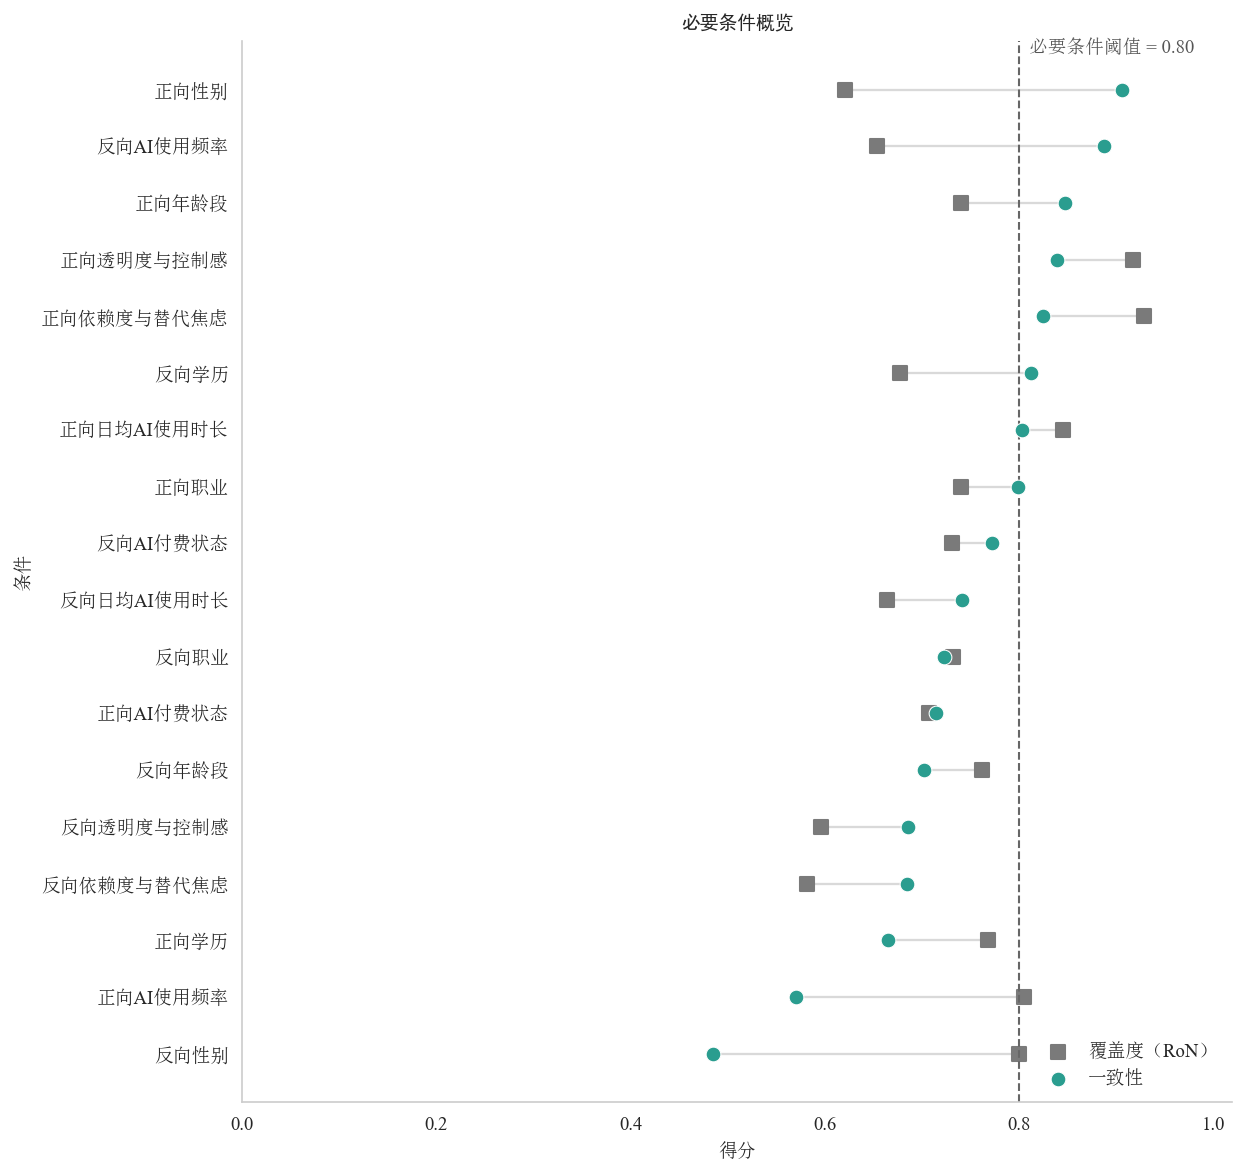

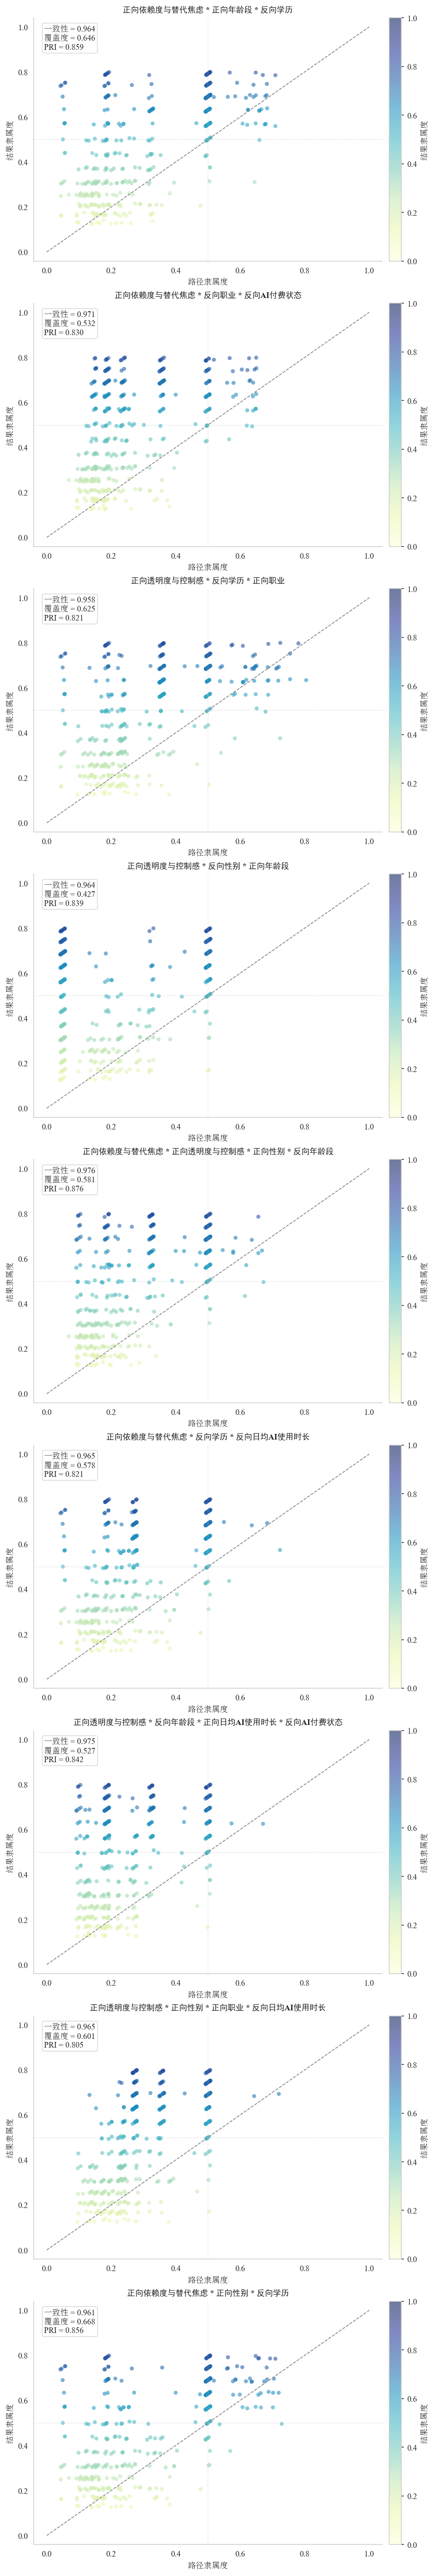

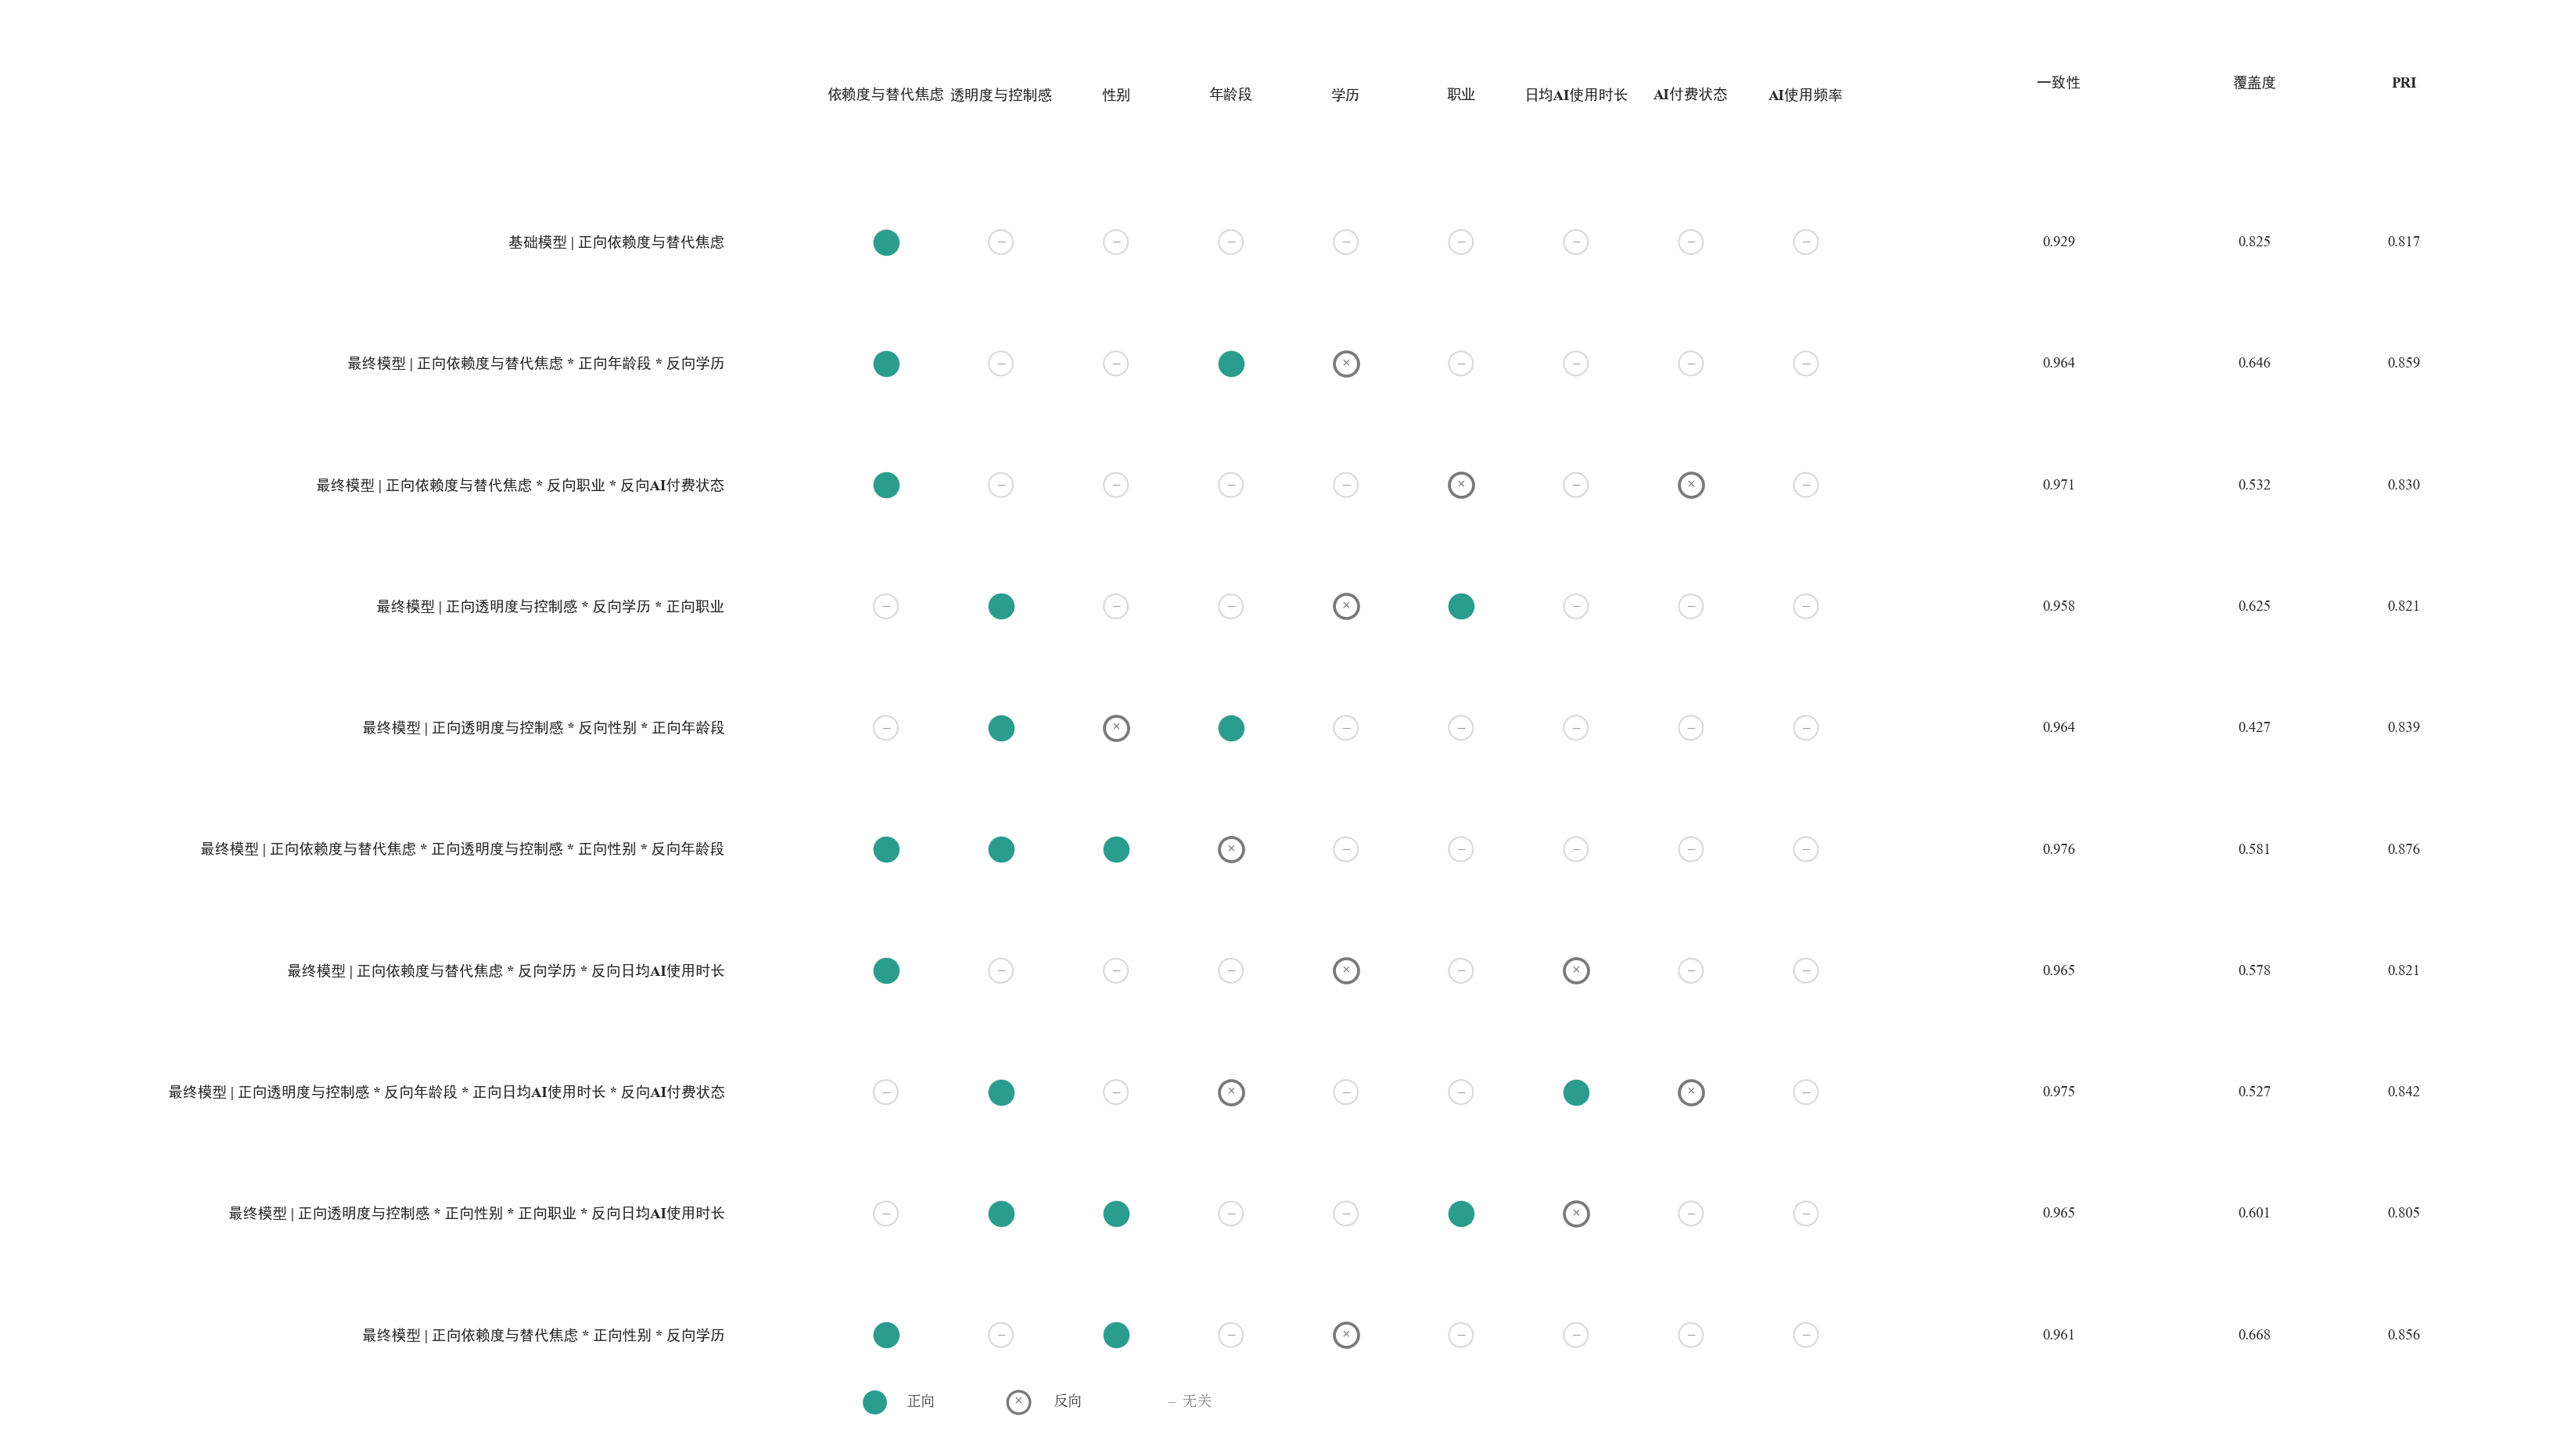

最终人口统计控制变量校准锚点：


,变量,标签,z_0.05（完全非隶属）,z_0.50（交叉点）,z_0.95（完全隶属）
0,性别,性别,0.0,0.0,1.0
1,年龄段,年龄段,2.0,3.0,6.0
2,学历,学历,4.0,5.0,6.0
3,职业,职业,1.0,3.0,6.0
4,日均AI使用时长,日均AI使用时长,1.0,3.0,4.0
5,AI付费状态,AI付费状态,0.0,1.0,2.0
6,AI使用频率,AI使用频率,1.0,2.0,2.0


最终人口统计控制必要条件分析：


,条件,一致性,覆盖度（RoN）,是否必要（≥0.80）
0,正向依赖度与替代焦虑,0.8252,0.9292,是 ✓
1,反向依赖度与替代焦虑,0.6843,0.5812,否
2,正向透明度与控制感,0.8391,0.9175,是 ✓
3,反向透明度与控制感,0.6857,0.5958,否
4,正向性别,0.9062,0.6209,是 ✓
5,反向性别,0.4850,0.8003,否
6,正向年龄段,0.8470,0.7400,是 ✓
7,反向年龄段,0.7018,0.7621,否
8,正向学历,0.6651,0.7685,否
9,反向学历,0.8127,0.6772,是 ✓


最终人口统计控制经验真值表（仅展示有案例的组态）：


...

最终人口统计控制模型 | 中间解


,组态路径,原始覆盖度,独特覆盖度,一致性,PRI
0,正向依赖度与替代焦虑 * 正向年龄段 * 反向学历,0.6458,0.0054,0.9637,0.8585
1,正向依赖度与替代焦虑 * 反向职业 * 反向AI付费状态,0.5319,0.0117,0.9712,0.8300
2,正向透明度与控制感 * 反向学历 * 正向职业,0.6254,0.0113,0.9578,0.8205
3,正向透明度与控制感 * 反向性别 * 正向年龄段,0.4273,0.0035,0.9636,0.8385
4,正向依赖度与替代焦虑 * 正向透明度与控制感 * 正向性别 * 反向年龄段,0.5812,0.0020,0.9764,0.8764
5,正向依赖度与替代焦虑 * 反向学历 * 反向日均AI使用时长,0.5782,0.0000,0.9651,0.8210
6,正向透明度与控制感 * 反向年龄段 * 正向日均AI使用时长 * 反向AI付费状态,0.5269,0.0040,0.9752,0.8420
7,正向透明度与控制感 * 正向性别 * 正向职业 * 反向日均AI使用时长,0.6008,0.0037,0.9654,0.8054
8,正向依赖度与替代焦虑 * 正向性别 * 反向学历,0.6676,0.0029,0.9614,0.8564


模型比较：


,模型,条件,简约解,一致性,原始覆盖度,PRI
0,基础模型（2个条件）,依赖度与替代焦虑、透明度与控制感,正向依赖度与替代焦虑,0.9292,0.8252,0.8174
1,最终人口统计控制模型,依赖度与替代焦虑、透明度与控制感 + 全部人口统计控制变量,正向依赖度与替代焦虑 * 正向年龄段 * 反向学历 + 正向依赖度与替代焦虑 * 反向职业 ...,0.9335,0.7926,0.8585


图已保存：
c:\Users\Administrator\Desktop\正大杯\code\outputs\fsqca_final_demographics_necessity_overview.png
c:\Users\Administrator\Desktop\正大杯\code\outputs\fsqca_final_demographics_solution_scatter.png
c:\Users\Administrator\Desktop\正大杯\code\outputs\fsqca_final_solution_path_diagram.png


In [ ]:
# 加入人口统计学控制变量
FSQCA_LABELS.update({
    '性别': '性别',
    '学历': '学历',
    '职业': '职业',
    'AI付费状态': 'AI付费状态',
})

FINAL_CTRL_COLS = DEMO_VARS.copy()


def calibrate_controls(control_columns: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    control_raw = sheet1_numeric.loc[fsqca_raw.index, control_columns].copy()
    control_cal = pd.DataFrame(index=control_raw.index)
    anchor_rows = []

    for column in control_columns:
        series = control_raw[column].astype(float)
        control_cal[column] = calibrate_logistic(series)
        anchor_rows.append({
            '变量': format_condition_base_name(column),
            '标签': VAR_META[column]['label'],
            'z_0.05（完全非隶属）': round(series.quantile(0.05), 4),
            'z_0.50（交叉点）': round(series.quantile(0.50), 4),
            'z_0.95（完全隶属）': round(series.quantile(0.95), 4),
        })

    return control_raw, control_cal, pd.DataFrame(anchor_rows)


def summarize_necessity(calibrated_df: pd.DataFrame, condition_names: list[str], outcome: np.ndarray) -> pd.DataFrame:
    rows = []
    for condition in condition_names:
        raw = calibrated_df[condition].values
        for is_negated, membership in [(False, raw), (True, 1 - raw)]:
            label = format_condition_name(condition, is_negated)
            rows.append({
                '条件': label,
                '一致性': round(consistency_nec(membership, outcome), 4),
                '覆盖度（RoN）': round(coverage_nec(membership, outcome), 4),
                '是否必要（≥0.80）': '是 ✓' if consistency_nec(membership, outcome) >= NEC_THRESH else '否',
            })
    return pd.DataFrame(rows)


def build_truth_table(calibrated_df: pd.DataFrame, condition_names: list[str], outcome: np.ndarray) -> pd.DataFrame:
    binary_df = (calibrated_df[condition_names] > 0.5).astype(int)
    truth_rows = []

    for config in product([0, 1], repeat=len(condition_names)):
        mask = np.ones(len(binary_df), dtype=bool)
        for idx, value in enumerate(config):
            mask &= (binary_df.iloc[:, idx].values == value)

        n_cases = int(mask.sum())
        if n_cases == 0:
            truth_rows.append({
                'config': config,
                'n': 0,
                'consist': np.nan,
                'PRI': np.nan,
                'raw_cov': np.nan,
                'outcome': pd.NA,
            })
            continue

        subset_parts = []
        full_parts = []
        for idx, value in enumerate(config):
            raw_subset = calibrated_df[condition_names[idx]].values[mask]
            raw_full = calibrated_df[condition_names[idx]].values
            subset_parts.append(raw_subset if value == 1 else 1 - raw_subset)
            full_parts.append(raw_full if value == 1 else 1 - raw_full)

        Zi_subset = np.minimum.reduce(subset_parts)
        Zi_full_config = np.minimum.reduce(full_parts)
        Yi_subset = outcome[mask]

        cons_value = consistency(Zi_subset, Yi_subset)
        pri_value = pri(Zi_subset, Yi_subset)
        cov_value = coverage(Zi_full_config, outcome)

        truth_rows.append({
            'config': config,
            'n': n_cases,
            'consist': round(cons_value, 4),
            'PRI': round(pri_value, 4),
            'raw_cov': round(cov_value, 4),
            'outcome': int((cons_value >= CONSIST_THRESH) and (pri_value >= PRI_THRESH) and (n_cases >= FREQ_THRESH)),
        })

    truth_df = pd.DataFrame(truth_rows)
    truth_df['组态表达式'] = truth_df['config'].apply(lambda cfg: fmt_config(cfg, condition_names))
    return truth_df


def solve_model(calibrated_df: pd.DataFrame, condition_names: list[str], outcome: np.ndarray, theory_direction: dict[int, str]):
    truth_df = build_truth_table(calibrated_df, condition_names, outcome)
    minterms_1 = [
        tuple(str(v) for v in row['config'])
        for _, row in truth_df.iterrows()
        if pd.notna(row['outcome']) and int(row['outcome']) == 1
    ]
    remainders = [
        tuple(str(v) for v in row['config'])
        for _, row in truth_df.iterrows()
        if pd.isna(row['outcome'])
    ]
    c_sol, p_sol, i_sol = solve_three(minterms_1, remainders, theory_direction)

    summary_rows = []
    solution_detail_map = {}
    for solution_name, solution_pis in [
        ('复杂解', c_sol),
        ('简约解', p_sol),
        ('中间解', i_sol),
    ]:
        detail_df, overall_consistency, overall_coverage = solution_metrics(solution_pis, outcome, calibrated_df, condition_names)
        solution_detail_map[solution_name] = detail_df
        summary_rows.append({
            '解类型': solution_name,
            '路径数': len(solution_pis),
            '表达式': ' + '.join(pi_to_str(pi, condition_names) for pi in solution_pis) or '—',
            '整体一致性': overall_consistency,
            '整体原始覆盖度': overall_coverage,
        })

    observed_truth_df = truth_df.loc[truth_df['n'] > 0, ['组态表达式', 'n', 'consist', 'PRI', 'raw_cov', 'outcome']].copy()
    observed_truth_df = observed_truth_df.sort_values(['outcome', 'consist', 'n'], ascending=[False, False, False]).reset_index(drop=True)
    observed_truth_df.columns = ['组态表达式', '样本量', '一致性', 'PRI', '原始覆盖度', '结果（1=属于）']

    parsimonious_df, parsimonious_consistency, parsimonious_coverage = solution_metrics(p_sol, outcome, calibrated_df, condition_names)

    return {
        'truth_df': truth_df,
        'observed_truth_df': observed_truth_df,
        'minterms_1': minterms_1,
        'remainders': remainders,
        'c_sol': c_sol,
        'p_sol': p_sol,
        'i_sol': i_sol,
        'summary_df': pd.DataFrame(summary_rows),
        'solution_detail_map': solution_detail_map,
        'parsimonious_df': parsimonious_df,
        'parsimonious_consistency': parsimonious_consistency,
        'parsimonious_coverage': parsimonious_coverage,
    }


def plot_necessity_overview(nec_df: pd.DataFrame, filename: str):
    plot_df = nec_df.sort_values(['是否必要（≥0.80）', '一致性', '覆盖度（RoN）'], ascending=[True, True, True]).reset_index(drop=True)
    y_pos = np.arange(len(plot_df))

    fig_height = max(4.8, 0.34 * len(plot_df) + 1.6)
    fig, ax = plt.subplots(figsize=(8.2, fig_height), constrained_layout=True)
    ax.hlines(
        y=y_pos,
        xmin=np.minimum(plot_df['一致性'], plot_df['覆盖度（RoN）']),
        xmax=np.maximum(plot_df['一致性'], plot_df['覆盖度（RoN）']),
        color='#D9D9D9',
        linewidth=1.1,
        zorder=1,
    )
    ax.scatter(
        plot_df['覆盖度（RoN）'],
        y_pos,
        marker='s',
        s=42,
        color=青橙灰配色[2],
        label='覆盖度（RoN）',
        zorder=2,
    )
    ax.scatter(
        plot_df['一致性'],
        y_pos,
        marker='o',
        s=50,
        color=青橙灰配色[0],
        edgecolors='white',
        linewidths=0.5,
        label='一致性',
        zorder=3,
    )
    ax.axvline(NEC_THRESH, color='#666666', linewidth=1.0, linestyle='--')
    ax.text(NEC_THRESH + 0.01, len(plot_df) - 0.35, f'必要条件阈值 = {NEC_THRESH:.2f}', fontsize=8, color='#555555')
    ax.set_xlim(0, 1.02)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df['条件'], fontsize=8.2)
    设置中文论文图表(ax, title='必要条件概览', xlabel='得分', ylabel='条件')
    ax.legend(loc='lower right', fontsize=8)
    设置图例字体(ax.get_legend())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    应用整图字体(fig)
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


Yi_full = fsqca_cal[OUTCOME_VAR].values
base_parsimonious_df, base_parsimonious_cons, base_parsimonious_cov = solution_metrics(p_sol, Yi_full, fsqca_cal, COND_NAMES)

final_ctrl_raw, final_ctrl_cal, final_ctrl_anchor_df = calibrate_controls(FINAL_CTRL_COLS)
final_cal = fsqca_cal[COND_NAMES].copy()
for column in FINAL_CTRL_COLS:
    final_cal[column] = final_ctrl_cal[column]

FINAL_CONDS = COND_NAMES + FINAL_CTRL_COLS
FINAL_THEORY = {0: '1', 1: '0'}
final_nec_df = summarize_necessity(final_cal, FINAL_CONDS, Yi_full)
final_result = solve_model(final_cal, FINAL_CONDS, Yi_full, FINAL_THEORY)

plot_necessity_overview(final_nec_df, 'fsqca_final_demographics_necessity_overview.png')
plot_solution_scatter(
    final_result['p_sol'],
    final_cal,
    FINAL_CONDS,
    Yi_full,
    'fsqca_final_demographics_solution_scatter.png',
    layout='vertical',
)

path_rows = []
for pi in p_sol:
    membership = solution_membership(pi, fsqca_cal, COND_NAMES)
    path_rows.append({
        'row_label': f'基础模型 | {pi_to_str(pi, COND_NAMES)}',
        'pi': pi,
        'condition_names': COND_NAMES,
        'consistency': consistency(membership, Yi_full),
        'coverage': coverage(membership, Yi_full),
        'pri': pri(membership, Yi_full),
    })
for pi in final_result['p_sol']:
    membership = solution_membership(pi, final_cal, FINAL_CONDS)
    path_rows.append({
        'row_label': f'最终模型 | {pi_to_str(pi, FINAL_CONDS)}',
        'pi': pi,
        'condition_names': FINAL_CONDS,
        'consistency': consistency(membership, Yi_full),
        'coverage': coverage(membership, Yi_full),
        'pri': pri(membership, Yi_full),
    })

plot_solution_path_chart(path_rows=path_rows, filename='fsqca_final_solution_path_diagram.png')

model_compare_df = pd.DataFrame([
    {
        '模型': '基础模型（2个条件）',
        '条件': '依赖度与替代焦虑、透明度与控制感',
        '简约解': ' + '.join(base_parsimonious_df['组态路径']) if not base_parsimonious_df.empty else '—',
        '一致性': base_parsimonious_cons,
        '原始覆盖度': base_parsimonious_cov,
        'PRI': base_parsimonious_df['PRI'].iloc[0] if not base_parsimonious_df.empty else np.nan,
    },
    {
        '模型': '最终人口统计控制模型',
        '条件': '依赖度与替代焦虑、透明度与控制感 + 全部人口统计控制变量',
        '简约解': ' + '.join(final_result['parsimonious_df']['组态路径']) if not final_result['parsimonious_df'].empty else '—',
        '一致性': final_result['parsimonious_consistency'],
        '原始覆盖度': final_result['parsimonious_coverage'],
        'PRI': final_result['parsimonious_df']['PRI'].iloc[0] if not final_result['parsimonious_df'].empty else np.nan,
    },
])

print('最终人口统计控制变量校准锚点：')
display(final_ctrl_anchor_df.reset_index(drop=True))
print('最终人口统计控制必要条件分析：')
display(final_nec_df.reset_index(drop=True))
print('最终人口统计控制经验真值表（仅展示有案例的组态）：')
display(final_result['observed_truth_df'])
print('最终人口统计控制三解比较：')
display(final_result['summary_df'].reset_index(drop=True))

for solution_name in ['复杂解', '简约解', '中间解']:
    print(f'最终人口统计控制模型 | {solution_name}')
    display(final_result['solution_detail_map'][solution_name].reset_index(drop=True))

print('模型比较：')
display(model_compare_df.reset_index(drop=True))
print('图已保存：')
print(OUTPUT_DIR / 'fsqca_final_demographics_necessity_overview.png')
print(OUTPUT_DIR / 'fsqca_final_demographics_solution_scatter.png')
print(OUTPUT_DIR / 'fsqca_final_solution_path_diagram.png')